# Case Study 1: Building a Mean-Variance Portfolio Pipeline

STAT 4170 — [Your Name]

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

RNG_SEED = 1
np.random.seed(RNG_SEED)

TICKERS = ["XLC", "XLY", "XLP", "XLE", "XLF", "XLV", "XLI", "XLB", "XLRE", "XLK", "XLU"]
MARKET = "SPY"
ALL_TICKERS = TICKERS + [MARKET]

## Section 1 - Data Pipeline

In [30]:
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
RETURNS_CACHE_PATH = DATA_DIR / "sector_etf_returns.csv"
HISTORY_START = "2018-01-01"  # before all 12 tickers existed; XLC (2018) and XLRE (2015) trim the front


def _most_recent_expected_trading_day() -> pd.Timestamp:
    """Most recent trading day whose closing price should already be available.

    Approximates the NYSE calendar with a Mon-Fri rule and a 4:00pm US/Eastern
    close (no holiday calendar). On a market holiday this triggers one harmless
    extra refresh that just reconfirms the prior close -- it never serves stale
    data silently.
    """
    now_et = datetime.now(ZoneInfo("America/New_York"))
    day = pd.Timestamp(now_et.date())
    if now_et.hour < 16:
        day -= pd.Timedelta(days=1)
    while day.weekday() >= 5:  # roll weekends back to Friday
        day -= pd.Timedelta(days=1)
    return day.normalize()


def get_sector_returns(tickers=ALL_TICKERS, start=HISTORY_START, cache_path=RETURNS_CACHE_PATH, force_refresh=False):
    """Load daily simple returns for `tickers` since `start`, using a disk cache.

    On the first call (or whenever the cache is missing or stale), downloads
    adjusted daily closes via yfinance, converts to simple returns
    r_t = P_t / P_{t-1} - 1, and writes the returns (not prices) to
    `cache_path`. Later calls read the CSV directly and only hit the network
    again once the cached data no longer reaches the most recent expected
    trading day.
    """
    expected_latest = _most_recent_expected_trading_day()

    if cache_path.exists() and not force_refresh:
        cached = pd.read_csv(cache_path, index_col=0, parse_dates=True)
        if cached.index.max() >= expected_latest:
            return cached

    prices = yf.download(tickers, start=start, auto_adjust=True, progress=False)["Close"]
    prices = prices[tickers].sort_index()
    returns = prices.pct_change().dropna(how="any")
    returns.to_csv(cache_path)
    return returns


returns = get_sector_returns()
print(returns.shape)
returns.head(10)

(2064, 12)


Ticker,XLC,XLY,XLP,XLE,XLF,XLV,XLI,XLB,XLRE,XLK,XLU,SPY
Date,,,,,,,,,,,,
2018-06-20,0.012410,0.004741,0.000979,0.004415,-0.002560,0.002121,0.000683,-0.003248,0.010794,0.002100,0.000797,0.001706
2018-06-21,-0.006129,-0.007123,0.001957,-0.018516,-0.002932,-0.005762,-0.012555,-0.010634,0.005967,-0.007684,0.003384,-0.006269
2018-06-22,0.004376,-0.001704,0.008201,0.019951,-0.004780,0.004494,0.003455,0.014563,0.008742,-0.003237,0.006944,0.001823
2018-06-25,-0.020598,-0.021739,0.005036,-0.020093,-0.010713,-0.009184,-0.012670,-0.015550,-0.002476,-0.020763,0.016552,-0.013613
2018-06-26,0.001658,0.007162,-0.004240,0.012629,-0.003361,-0.003089,0.003766,0.003819,0.005275,0.004039,0.001163,0.002214
2018-06-27,-0.008722,-0.012947,-0.002129,0.013410,-0.012364,-0.008463,-0.008060,-0.003113,-0.002778,-0.013648,0.004840,-0.008284
2018-06-28,0.009980,0.007852,0.000000,-0.001323,0.008726,0.001322,0.001401,0.003816,0.009904,0.012234,-0.000385,0.005718
2018-06-29,-0.001210,0.001741,-0.000582,0.006227,0.000000,0.002041,0.002099,0.003456,0.002452,-0.000431,0.001542,0.001440
2018-07-02,0.006259,0.001372,-0.005822,-0.014748,0.004889,0.003115,0.002234,-0.005339,-0.005808,0.008925,0.007121,0.002138


**Return convention.** We use daily **simple (linear) returns**, $r_t = P_t / P_{t-1} - 1$, for every ticker throughout this notebook (not log returns).

**Cache design and invalidation logic.** `get_sector_returns` caches the derived returns (not raw prices) to `data/sector_etf_returns.csv`, a path relative to the notebook so it works on any machine. The first call downloads adjusted daily closes for all 12 tickers, converts them to simple returns, drops the leading `NaN` row from `pct_change`, and writes the result to disk. Later calls read the CSV first and compare the last cached date to `_most_recent_expected_trading_day()`, which approximates "the last trading day that should already have closed" using a Mon-Fri, 4:00pm US/Eastern rule. If the cache already reaches that date, the function returns it with no network call; otherwise it re-downloads. So a grader with no cache always gets a fresh download on the first run, and re-running later the same day (or any day with no new bars) never touches the network.

## Section 2 - Parameter and Model Uncertainty

### Section 2.1 - Simulation Study (No Model Risk)

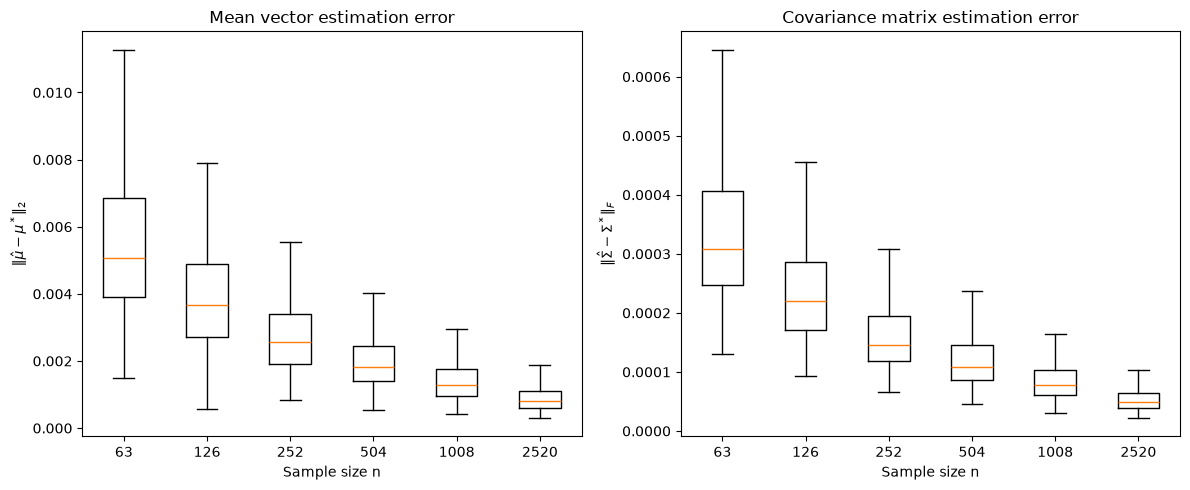

Empirical convergence rate: mu error ~ n^-0.503, Sigma error ~ n^-0.498


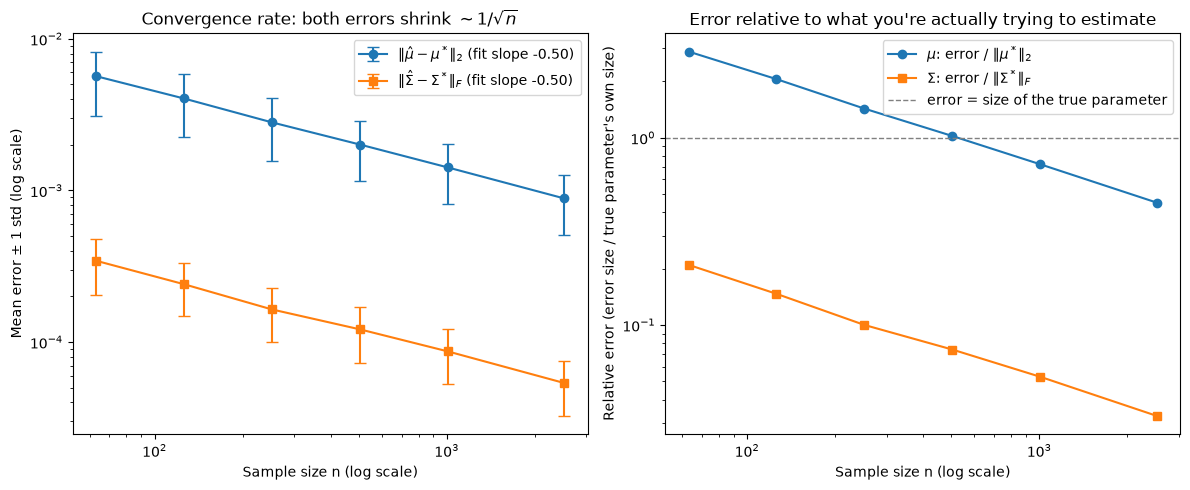

,mu_mean,mu_std,sigma_mean,sigma_std,mu_rel_error,sigma_rel_error
n,,,,,,
63,0.005674,0.002573,0.000344,0.000138,2.884812,0.209635
126,0.004042,0.001797,0.000241,0.000093,2.055147,0.146772
252,0.002813,0.001251,0.000164,0.000065,1.430168,0.100075
504,0.002009,0.000861,0.000121,0.000048,1.021360,0.073960
1008,0.001419,0.000600,0.000087,0.000034,0.721304,0.052906
2520,0.000887,0.000380,0.000054,0.000021,0.450721,0.032750


In [31]:
mu_star = returns.mean()
Sigma_star = returns.cov()

N_GRID = [63, 126, 252, 504, 1008, 2520]
N_REPS = 1000

mu_errors = {n: [] for n in N_GRID}
Sigma_errors = {n: [] for n in N_GRID}

mu_star_vec = mu_star.values
Sigma_star_mat = Sigma_star.values

for n in N_GRID:
    for _ in range(N_REPS):
        sample = np.random.multivariate_normal(mu_star_vec, Sigma_star_mat, size=n)
        mu_hat = sample.mean(axis=0)
        Sigma_hat = np.cov(sample, rowvar=False)

        mu_errors[n].append(np.linalg.norm(mu_hat - mu_star_vec))
        Sigma_errors[n].append(np.linalg.norm(Sigma_hat - Sigma_star_mat, ord="fro"))

mu_error_df = pd.DataFrame(mu_errors)
Sigma_error_df = pd.DataFrame(Sigma_errors)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot([mu_error_df[n] for n in N_GRID], tick_labels=N_GRID, showfliers=False)
axes[0].set_xlabel("Sample size n")
axes[0].set_ylabel(r"$\|\hat{\mu} - \mu^*\|_2$")
axes[0].set_title("Mean vector estimation error")

axes[1].boxplot([Sigma_error_df[n] for n in N_GRID], tick_labels=N_GRID, showfliers=False)
axes[1].set_xlabel("Sample size n")
axes[1].set_ylabel(r"$\|\hat{\Sigma} - \Sigma^*\|_F$")
axes[1].set_title("Covariance matrix estimation error")
plt.tight_layout()
plt.show()

# --- convergence rate + relative-error summary ---
summary_df = pd.DataFrame({
    "n": N_GRID,
    "mu_mean": [mu_error_df[n].mean() for n in N_GRID],
    "mu_std": [mu_error_df[n].std() for n in N_GRID],
    "sigma_mean": [Sigma_error_df[n].mean() for n in N_GRID],
    "sigma_std": [Sigma_error_df[n].std() for n in N_GRID],
}).set_index("n")

mu_star_norm = np.linalg.norm(mu_star_vec)
Sigma_star_norm = np.linalg.norm(Sigma_star_mat, ord="fro")
summary_df["mu_rel_error"] = summary_df["mu_mean"] / mu_star_norm
summary_df["sigma_rel_error"] = summary_df["sigma_mean"] / Sigma_star_norm

log_n = np.log(N_GRID)
mu_slope, _ = np.polyfit(log_n, np.log(summary_df["mu_mean"]), 1)
sigma_slope, _ = np.polyfit(log_n, np.log(summary_df["sigma_mean"]), 1)
print(f"Empirical convergence rate: mu error ~ n^{mu_slope:.3f}, Sigma error ~ n^{sigma_slope:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].errorbar(N_GRID, summary_df["mu_mean"], yerr=summary_df["mu_std"], marker="o", capsize=4,
                  label=rf"$\|\hat{{\mu}}-\mu^*\|_2$ (fit slope {mu_slope:.2f})")
axes[0].errorbar(N_GRID, summary_df["sigma_mean"], yerr=summary_df["sigma_std"], marker="s", capsize=4,
                  label=rf"$\|\hat{{\Sigma}}-\Sigma^*\|_F$ (fit slope {sigma_slope:.2f})")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Sample size n (log scale)")
axes[0].set_ylabel("Mean error ± 1 std (log scale)")
axes[0].set_title(r"Convergence rate: both errors shrink $\sim 1/\sqrt{n}$")
axes[0].legend()

axes[1].plot(N_GRID, summary_df["mu_rel_error"], marker="o", label=r"$\mu$: error / $\|\mu^*\|_2$")
axes[1].plot(N_GRID, summary_df["sigma_rel_error"], marker="s", label=r"$\Sigma$: error / $\|\Sigma^*\|_F$")
axes[1].axhline(1.0, color="gray", linestyle="--", linewidth=1, label="error = size of the true parameter")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Sample size n (log scale)")
axes[1].set_ylabel("Relative error (error size / true parameter's own size)")
axes[1].set_title("Error relative to what you're actually trying to estimate")
axes[1].legend()
plt.tight_layout()
plt.show()

summary_df

**Convergence rate.** Both errors shrink at about the same rate: slope $-0.50$ for $\mu$ and $-0.50$ for $\Sigma$, matching the standard $1/\sqrt{n}$ rate. So the difference below is about signal size, not speed.

**$\mu$.** Relative error stays above 1 (bigger than $\mu^*$ itself) through $n=504$, and only drops below 1 at $n=1008$ (0.72); even at $n=2520$ it's still 0.45. $\mu$ is hard to pin down at any realistic sample size -- part of why 2.2 uses CAPM instead of the plug-in sample mean.

**$\Sigma$.** Relative error is about 10% at $n=252$, 5% at $n=1008$, 3% at $n=2520$. $n=1008$ is a reasonable point to treat $\hat\Sigma$ as usable.

### Section 2.2 - Model Uncertainty on Real Data

CAPM per-asset alpha / beta / idiosyncratic variance:


,alpha,beta,resid_var
XLC,-0.000095,0.986307,0.000052
XLY,-0.000201,1.112196,0.000046
XLP,0.000066,0.525781,0.000057
XLE,0.000036,0.944089,0.000268
XLF,-0.000089,1.006482,0.000066
XLV,0.000034,0.687473,0.000052
XLI,-0.000036,0.973298,0.000042
XLB,-0.000138,0.944244,0.000061
XLRE,-0.000122,0.807891,0.000093
XLK,0.000170,1.287723,0.000043



Mean vector comparison:


,sample (annualized %),CAPM (annualized %),abs diff
XLC,13.269878,13.269878,1.598721e-14
XLF,13.751673,13.751673,1.598721e-14
XLP,10.011226,10.011226,1.243450e-14
XLE,15.900992,15.900992,1.243450e-14
XLV,11.784415,11.784415,1.065814e-14
XLU,11.714345,11.714345,8.881784e-15
XLK,24.740180,24.740180,7.105427e-15
XLB,11.512043,11.512043,7.105427e-15
XLI,14.560965,14.560965,3.552714e-15
XLRE,9.752878,9.752878,3.552714e-15


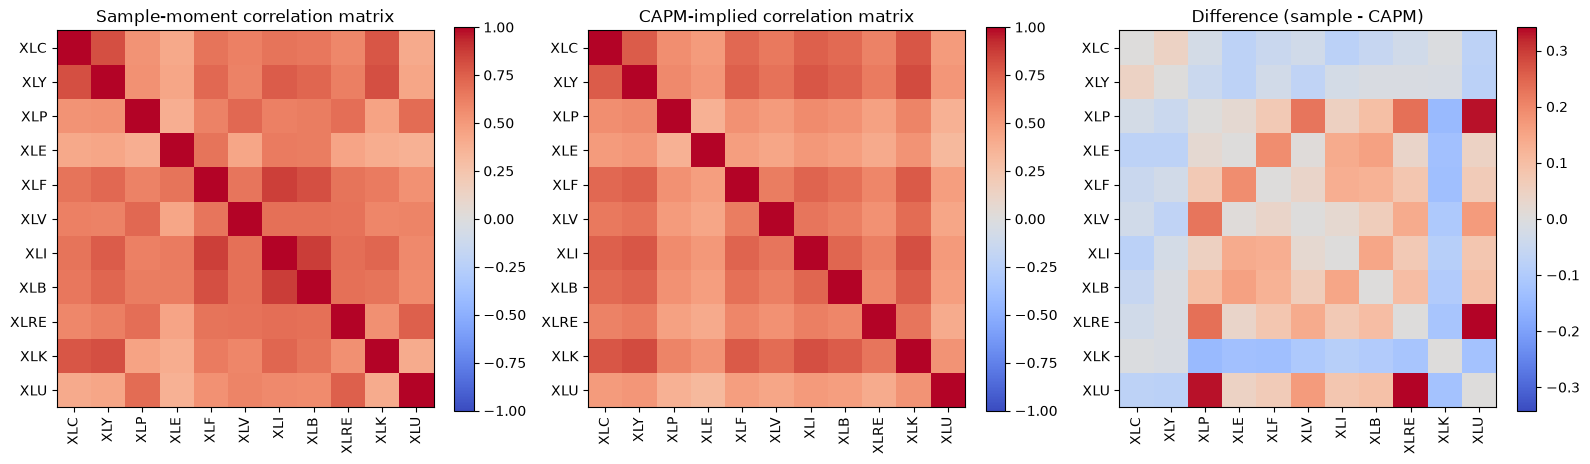


Largest |sample corr - CAPM corr| off-diagonal pairs:


Ticker  Ticker
XLRE    XLU       0.341751
XLP     XLU       0.332019
XLRE    XLP       0.234201
XLP     XLV       0.225339
XLF     XLE       0.191266
XLV     XLU       0.165759
XLB     XLE       0.155889
XLI     XLB       0.147746
XLP     XLK      -0.144589
XLRE    XLV       0.138119
Name: corr diff (sample - CAPM), dtype: float64

In [32]:
# --- Method 1: sample moments (just the 11 sector ETFs; SPY excluded since it's the CAPM factor, not a target) ---
mu_sample = returns[TICKERS].mean()
Sigma_sample = returns[TICKERS].cov()
Corr_sample = returns[TICKERS].corr()

# --- Method 2: single-factor CAPM via matrix multiplication (module 2) ---
X = np.column_stack([np.ones(len(returns)), returns[MARKET].values])  # (n, 2): [1, r_SPY]
Y = returns[TICKERS].values                                            # (n, 11)

B_hat = np.linalg.lstsq(X, Y, rcond=None)[0]   # (2, 11): row 0 = alpha_i, row 1 = beta_i
alpha_hat, beta_hat = B_hat[0], B_hat[1]

resids = Y - X @ B_hat
resid_var = resids.var(axis=0, ddof=1)          # idiosyncratic variance per asset (CAPM assumes these are uncorrelated across assets)

r_mkt_mean = returns[MARKET].mean()
r_mkt_var = returns[MARKET].var(ddof=1)

# Law of total expectation: E[mu_i] = alpha_i + beta_i * E[r_market]
mu_capm = pd.Series(alpha_hat + beta_hat * r_mkt_mean, index=TICKERS)

# Law of total covariance: Sigma = beta beta^T * var(r_market) + diag(idiosyncratic variances)
Sigma_capm = pd.DataFrame(
    np.outer(beta_hat, beta_hat) * r_mkt_var + np.diag(resid_var),
    index=TICKERS, columns=TICKERS,
)
Corr_capm = Sigma_capm / np.sqrt(np.outer(np.diag(Sigma_capm), np.diag(Sigma_capm)))

capm_params = pd.DataFrame({"alpha": alpha_hat, "beta": beta_hat, "resid_var": resid_var}, index=TICKERS)
print("CAPM per-asset alpha / beta / idiosyncratic variance:")
display(capm_params)

# --- Side-by-side mean vectors (annualized, x252, for readability) ---
mu_compare = pd.DataFrame({
    "sample (annualized %)": mu_sample * 252 * 100,
    "CAPM (annualized %)": mu_capm * 252 * 100,
})
mu_compare["abs diff"] = (mu_compare["sample (annualized %)"] - mu_compare["CAPM (annualized %)"]).abs()
print("\nMean vector comparison:")
display(mu_compare.sort_values("abs diff", ascending=False))

# --- Covariance / correlation comparison plots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

im0 = axes[0].imshow(Corr_sample, vmin=-1, vmax=1, cmap="coolwarm")
axes[0].set_xticks(range(len(TICKERS))); axes[0].set_xticklabels(TICKERS, rotation=90)
axes[0].set_yticks(range(len(TICKERS))); axes[0].set_yticklabels(TICKERS)
axes[0].set_title("Sample-moment correlation matrix")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(Corr_capm, vmin=-1, vmax=1, cmap="coolwarm")
axes[1].set_xticks(range(len(TICKERS))); axes[1].set_xticklabels(TICKERS, rotation=90)
axes[1].set_yticks(range(len(TICKERS))); axes[1].set_yticklabels(TICKERS)
axes[1].set_title("CAPM-implied correlation matrix")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

corr_diff = Corr_sample - Corr_capm
lim = np.abs(corr_diff.values).max()
im2 = axes[2].imshow(corr_diff, vmin=-lim, vmax=lim, cmap="coolwarm")
axes[2].set_xticks(range(len(TICKERS))); axes[2].set_xticklabels(TICKERS, rotation=90)
axes[2].set_yticks(range(len(TICKERS))); axes[2].set_yticklabels(TICKERS)
axes[2].set_title("Difference (sample - CAPM)")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

# --- Which off-diagonal pairs differ the most? ---
diff_stacked = corr_diff.where(~np.eye(len(TICKERS), dtype=bool)).stack()
top_diff_pairs = diff_stacked.abs().sort_values(ascending=False).drop_duplicates().head(10)
print("\nLargest |sample corr - CAPM corr| off-diagonal pairs:")
display(diff_stacked.loc[top_diff_pairs.index].rename("corr diff (sample - CAPM)"))

**Mean vector.** Sample and CAPM means match almost exactly (differences around $10^{-14}$, floating-point noise). This is expected: OLS with an intercept always fits through the average, so $\hat\alpha_i + \hat\beta_i\bar r_{\text{SPY}}$ reduces to the sample mean itself. CAPM's effect here is entirely in $\Sigma$, not $\mu$.

**Why correlation instead of covariance.** Correlation is on a fixed $[-1,1]$ scale, so differences between pairs are directly comparable regardless of each asset's own volatility.

**Covariance / correlation.** The two methods disagree a lot. The ten largest correlation gaps between the sample and CAPM matrices range from about 0.14 to 0.34, which is large relative to the full possible range of 2.

**Sensitivity.** Since $\mathbf{w}^*$ depends on $\hat\Sigma^{-1}$, a correlation gap of this size can noticeably change the optimal weights. The choice of estimation method matters here, not just sampling noise within one method.

**Where the gap comes from.** Nine of the ten largest gaps have sample correlation higher than CAPM's -- those sector pairs move together more than a shared SPY beta explains. One pair (XLP-XLK) goes the other way, with CAPM implying a higher correlation than what actually happened.

### Section 2.3 - Bootstrap and Rolling Window

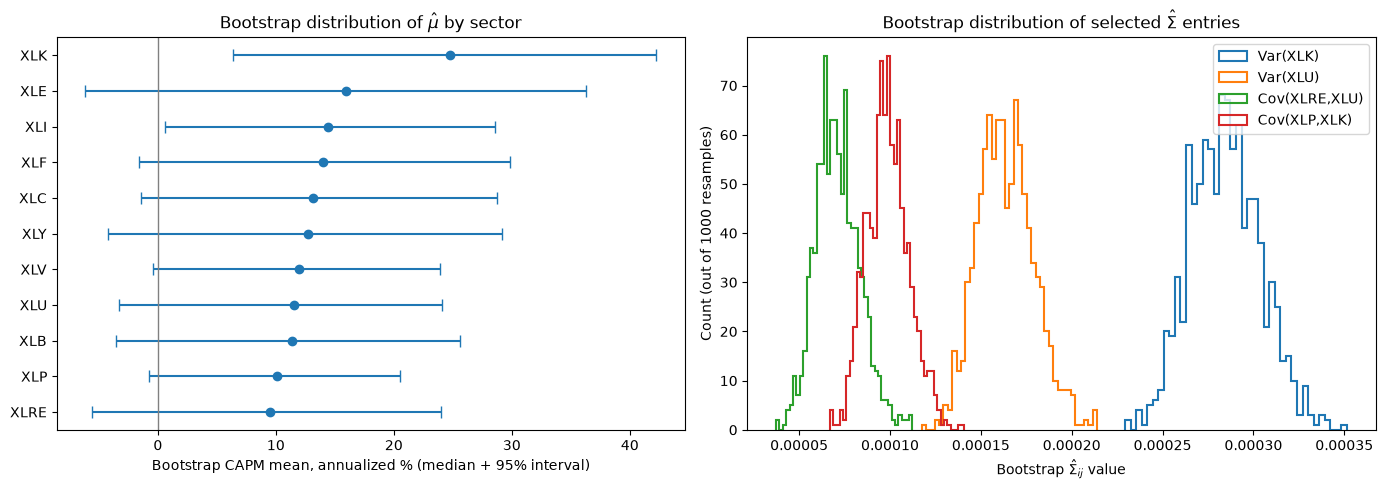

In [33]:
def fit_capm(ret_df):
    """Single-factor CAPM fit (as in 2.2): returns (mu_hat, Sigma_hat) as plain numpy arrays."""
    X = np.column_stack([np.ones(len(ret_df)), ret_df[MARKET].values])
    Y = ret_df[TICKERS].values
    B = np.linalg.lstsq(X, Y, rcond=None)[0]
    alpha, beta = B[0], B[1]
    resid_var = (Y - X @ B).var(axis=0, ddof=1)
    r_mkt_mean = ret_df[MARKET].mean()
    r_mkt_var = ret_df[MARKET].var(ddof=1)
    mu = alpha + beta * r_mkt_mean
    Sigma = np.outer(beta, beta) * r_mkt_var + np.diag(resid_var)
    return mu, Sigma


# --- Bootstrap: resample days with replacement, refit CAPM each time ---
N_BOOT = 1000
n_obs = len(returns)
rng = np.random.default_rng(RNG_SEED)

boot_mu = np.zeros((N_BOOT, len(TICKERS)))
boot_Sigma = np.zeros((N_BOOT, len(TICKERS), len(TICKERS)))

for b in range(N_BOOT):
    idx = rng.integers(0, n_obs, size=n_obs)
    resampled = returns.iloc[idx]
    boot_mu[b], boot_Sigma[b] = fit_capm(resampled)

# Forest plot: bootstrap mean (annualized %) and 95% percentile interval per sector
mu_annual = boot_mu * 252 * 100
mu_median = np.median(mu_annual, axis=0)
mu_lo = np.percentile(mu_annual, 2.5, axis=0)
mu_hi = np.percentile(mu_annual, 97.5, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = np.argsort(mu_median)
axes[0].errorbar(mu_median[order], np.arange(len(TICKERS)),
                  xerr=[mu_median[order] - mu_lo[order], mu_hi[order] - mu_median[order]],
                  fmt="o", capsize=4)
axes[0].set_yticks(np.arange(len(TICKERS)))
axes[0].set_yticklabels(np.array(TICKERS)[order])
axes[0].axvline(0, color="gray", linewidth=1)
axes[0].set_xlabel("Bootstrap CAPM mean, annualized % (median + 95% interval)")
axes[0].set_title("Bootstrap distribution of $\\hat{\\mu}$ by sector")

# Distribution of a few Sigma_hat entries: two variances, two covariance pairs
tickers_idx = {t: i for i, t in enumerate(TICKERS)}
pairs_to_show = [("XLK", "XLK"), ("XLU", "XLU"), ("XLRE", "XLU"), ("XLP", "XLK")]
for (a, c) in pairs_to_show:
    ia, ic = tickers_idx[a], tickers_idx[c]
    label = f"Var({a})" if a == c else f"Cov({a},{c})"
    axes[1].hist(boot_Sigma[:, ia, ic], bins=40, histtype="step", linewidth=1.5, label=label)
axes[1].set_xlabel("Bootstrap $\\hat{\\Sigma}_{ij}$ value")
axes[1].set_ylabel("Count (out of 1000 resamples)")
axes[1].set_title("Bootstrap distribution of selected $\\hat{\\Sigma}$ entries")
axes[1].legend()

plt.tight_layout()
plt.show()

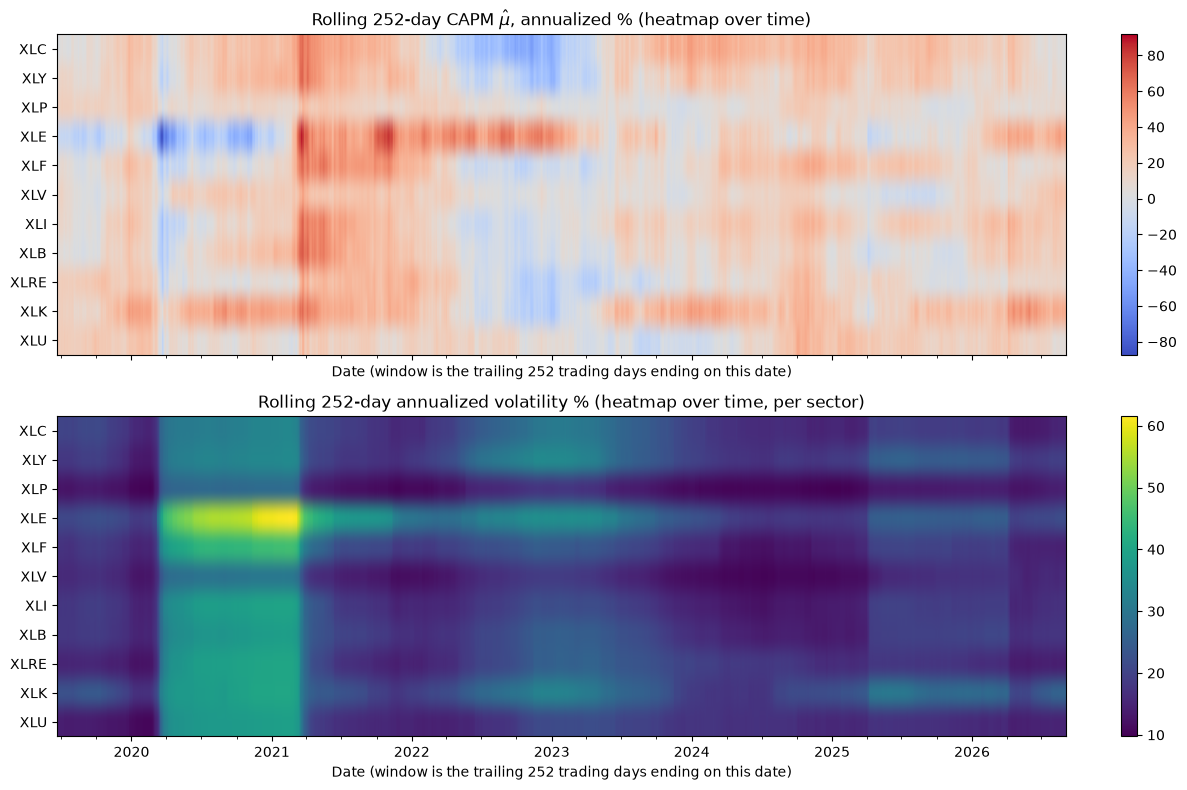

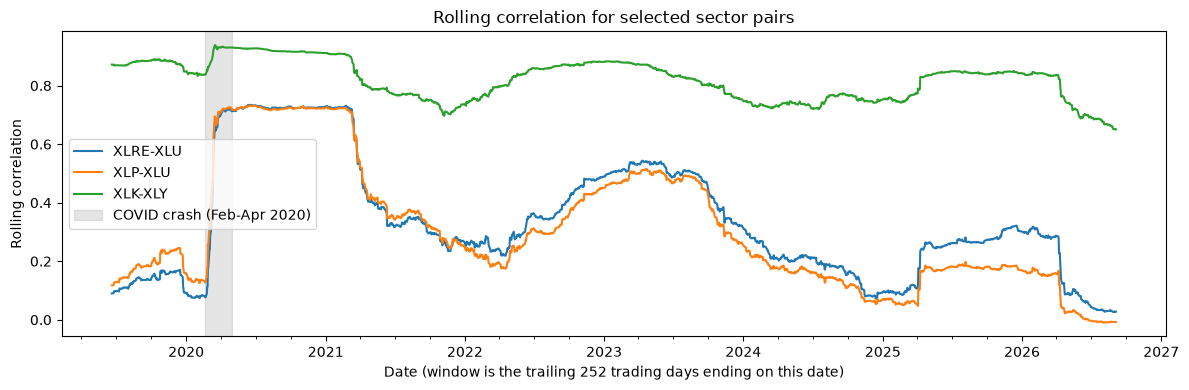

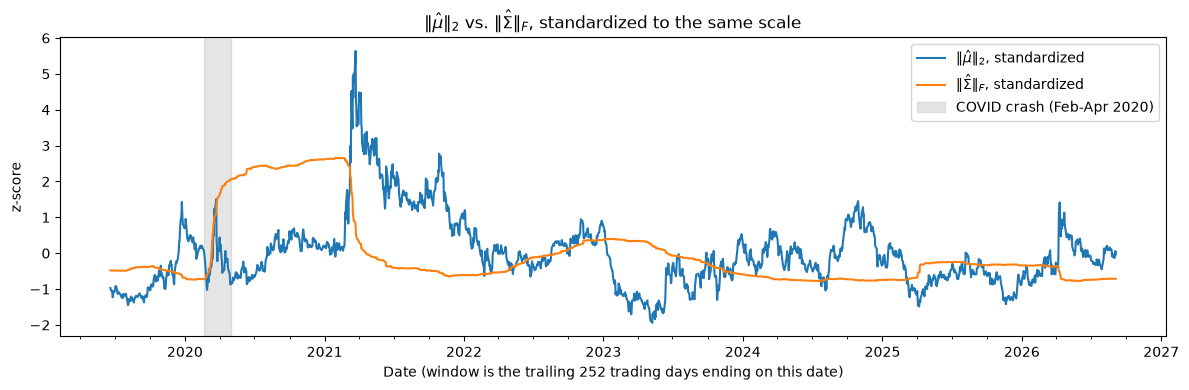

Average |z-score| over time -- ||mu_hat||: 0.72  ||Sigma_hat||_F: 0.72
Largest |z-score| reached -- ||mu_hat||: 5.64  ||Sigma_hat||_F: 2.66
Correlation between the two raw series over time: 0.036


In [34]:
import matplotlib.dates as mdates

# --- Rolling window: refit CAPM on each trailing 252-day window, in time order ---
WINDOW = 252
roll_dates = returns.index[WINDOW - 1:]
n_windows = len(roll_dates)

roll_mu = np.zeros((n_windows, len(TICKERS)))
roll_vol = np.zeros((n_windows, len(TICKERS)))  # annualized volatility (sqrt of diag Sigma) -- per-asset only
roll_mu_norm = np.zeros(n_windows)              # ||mu_hat||_2, daily units -- mu_hat as a whole vector
roll_Sigma_fro = np.zeros(n_windows)            # ||Sigma_hat||_F, daily units -- Sigma_hat as a whole matrix

pairs_to_track = [("XLRE", "XLU"), ("XLP", "XLU"), ("XLK", "XLY")]
roll_corr = {pair: np.zeros(n_windows) for pair in pairs_to_track}

for i in range(n_windows):
    window_df = returns.iloc[i:i + WINDOW]
    mu_t, Sigma_t = fit_capm(window_df)
    roll_mu[i] = mu_t
    roll_vol[i] = np.sqrt(np.diag(Sigma_t)) * np.sqrt(252)
    roll_mu_norm[i] = np.linalg.norm(mu_t)
    roll_Sigma_fro[i] = np.linalg.norm(Sigma_t, ord="fro")

    for (a, c) in pairs_to_track:
        ia, ic = tickers_idx[a], tickers_idx[c]
        roll_corr[(a, c)][i] = Sigma_t[ia, ic] / np.sqrt(Sigma_t[ia, ia] * Sigma_t[ic, ic])

roll_mu_annual = roll_mu * 252 * 100
roll_vol_pct = roll_vol * 100
date_nums = mdates.date2num(roll_dates)
covid_start, covid_end = pd.Timestamp("2020-02-20"), pd.Timestamp("2020-04-30")


def format_date_axis(ax):
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator([1, 4, 7, 10]))
    ax.set_xlabel("Date (window is the trailing 252 trading days ending on this date)")


# --- Heatmaps: mu and volatility, per sector (both have colorbars, so their axes compress the same way) ---
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

im0 = axes[0].imshow(roll_mu_annual.T, aspect="auto", cmap="coolwarm",
                      extent=[date_nums[0], date_nums[-1], len(TICKERS), 0])
axes[0].set_yticks(np.arange(len(TICKERS)) + 0.5)
axes[0].set_yticklabels(TICKERS)
axes[0].set_title(r"Rolling 252-day CAPM $\hat{\mu}$, annualized % (heatmap over time)")
plt.colorbar(im0, ax=axes[0], fraction=0.03)

im1 = axes[1].imshow(roll_vol_pct.T, aspect="auto", cmap="viridis",
                      extent=[date_nums[0], date_nums[-1], len(TICKERS), 0])
axes[1].set_yticks(np.arange(len(TICKERS)) + 0.5)
axes[1].set_yticklabels(TICKERS)
axes[1].set_title(r"Rolling 252-day annualized volatility % (heatmap over time, per sector)")
plt.colorbar(im1, ax=axes[1], fraction=0.03)

for ax in axes:
    format_date_axis(ax)

plt.tight_layout()
plt.show()

# --- Correlation: its own figure, no colorbar, so its axis isn't compressed relative to the heatmaps ---
fig, ax = plt.subplots(figsize=(12, 4))
for pair, series in roll_corr.items():
    ax.plot(roll_dates, series, label=f"{pair[0]}-{pair[1]}")
ax.axvspan(covid_start, covid_end, color="gray", alpha=0.2, label="COVID crash (Feb-Apr 2020)")
ax.set_ylabel("Rolling correlation")
ax.set_title("Rolling correlation for selected sector pairs")
ax.legend()
format_date_axis(ax)

plt.tight_layout()
plt.show()

# --- The actual comparison we care about: mu_hat as a whole vector vs Sigma_hat as a whole matrix ---
# Per-sector volatility above only looks at the diagonal of Sigma_hat. The Frobenius norm folds in
# every variance AND covariance entry, which is what the optimizer (Sigma_hat^-1 mu_hat) actually
# uses. ||mu_hat|| is in return units and ||Sigma_hat||_F is in return-units-squared, so the two
# aren't comparable in raw form -- standardizing each to its own z-score removes that mismatch and
# is unaffected by any constant scaling (e.g. annualizing), so we just use daily units directly.
mu_norm_s = pd.Series(roll_mu_norm, index=roll_dates)
sigma_fro_s = pd.Series(roll_Sigma_fro, index=roll_dates)
mu_norm_z = (mu_norm_s - mu_norm_s.mean()) / mu_norm_s.std()
sigma_fro_z = (sigma_fro_s - sigma_fro_s.mean()) / sigma_fro_s.std()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(roll_dates, mu_norm_z, label=r"$\|\hat{\mu}\|_2$, standardized")
ax.plot(roll_dates, sigma_fro_z, label=r"$\|\hat{\Sigma}\|_F$, standardized")
ax.axvspan(covid_start, covid_end, color="gray", alpha=0.2, label="COVID crash (Feb-Apr 2020)")
ax.set_ylabel("z-score")
ax.set_title(r"$\|\hat{\mu}\|_2$ vs. $\|\hat{\Sigma}\|_F$, standardized to the same scale")
ax.legend()
format_date_axis(ax)
plt.tight_layout()
plt.show()

print("Average |z-score| over time -- ||mu_hat||:", round(mu_norm_z.abs().mean(), 2),
      " ||Sigma_hat||_F:", round(sigma_fro_z.abs().mean(), 2))
print("Largest |z-score| reached -- ||mu_hat||:", round(mu_norm_z.abs().max(), 2),
      " ||Sigma_hat||_F:", round(sigma_fro_z.abs().max(), 2))
print("Correlation between the two raw series over time:", round(mu_norm_s.corr(sigma_fro_s), 3))

**Bootstrap.** $\hat\mu$ is volatile: 8 of 11 sectors have a 95% interval that includes zero. $\hat\Sigma$ is much more tightly distributed around its point estimate. This matches 2.1: $\mu$ is the harder parameter to pin down.

**Rolling window.** $\hat\mu$ is noisy over time and flips sign often in the top heatmap (blue to red). The per-sector volatility heatmap only looks at the diagonal of $\hat\Sigma$, so it's not the full picture -- the optimizer uses all of $\hat\Sigma$, variances and covariances together. Using $\|\hat\Sigma\|_F$ (the whole matrix) instead of just volatility gives a fair comparison to $\|\hat\mu\|_2$ (the whole mean vector), both standardized to the same scale: average variability is close (0.72 for $\mu$, also 0.72 for $\Sigma$), but $\mu$ reaches a much larger extreme (max z of 5.6 vs. 2.7 for $\Sigma$), and the two series are barely correlated with each other (0.04) -- they don't necessarily spike at the same time.

Overall $\Sigma$ is still the steadier estimate: it stays in a more predictable range and doesn't flip sign, while $\mu$ swings further and occasionally moves to an extreme with no clear counterpart in $\Sigma$.

**Regimes.** Crashes raise correlation and volatility across sectors -- COVID (Feb-Apr 2020) is the clearest example, and similar tariff-driven selloffs do the same. Because the window is 252 trading days, one crash keeps distorting the rolling estimate for about a year afterward, which is why volatility and correlation stay elevated well past the event itself and only fall once the crash days roll out of the window. $\|\hat\Sigma\|_F$ peaks in a window dated January 2021, for the same reason.

There's also a separate low-$\mu$ period in the middle of the sample, from mid-2022 to early 2023, bottoming around October 2022 -- distinct from the COVID trough and consistent with the 2022 rate-hike selloff.

### Section 2.4 - Dimension vs. Sample Size

Real beta: mean=0.898, std=0.224
Real idiosyncratic variance: mean=0.000081, range=[0.000042, 0.000268]
k=12 matches 2.1 real estimates exactly: True


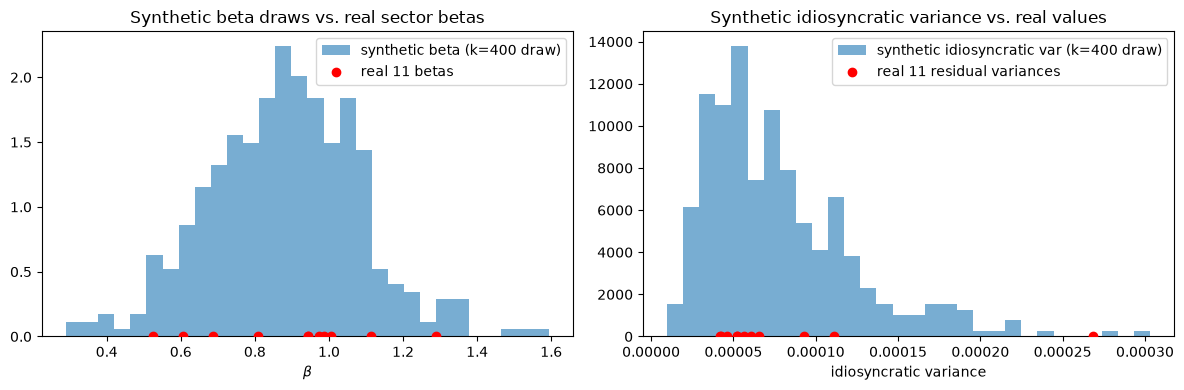

In [35]:
# --- Ground truth mu*(k), Sigma*(k) for arbitrary k ---
# k <= 12: subset of the real full-sample estimates from 2.1 (mu_star, Sigma_star -- 12 columns,
#          TICKERS + SPY, so we have exactly 12 real assets to draw from).
# k > 12:  no more real assets exist, so we build a synthetic k-asset universe using the same
#          one-factor structure as the 2.2 CAPM fit: Sigma*(k) = diag(D) + beta beta^T * sigma_m^2.
#          beta and D are drawn from distributions fit to the 11 real CAPM betas / residual
#          variances from 2.2, so the synthetic universe still reflects real, estimated market
#          behavior rather than made-up numbers.

beta_fit_mean, beta_fit_std = beta_hat.mean(), beta_hat.std(ddof=1)
log_resid_var = np.log(resid_var)
logvar_fit_mean, logvar_fit_std = log_resid_var.mean(), log_resid_var.std(ddof=1)  # log-normal: residual variances must stay positive, and the real 11 are right-skewed

K_GRID = [5, 12, 50, 150, 252, 500, 1000]
rng24 = np.random.default_rng(RNG_SEED)


def ground_truth(k):
    """Return (mu_star_k, Sigma_star_k), the (synthetic, for k>12) true parameters for a k-asset universe."""
    if k <= 12:
        mu_k = mu_star_vec[:k]
        Sigma_k = Sigma_star_mat[:k, :k]
    else:
        beta_k = rng24.normal(beta_fit_mean, beta_fit_std, size=k)
        D_k = np.exp(rng24.normal(logvar_fit_mean, logvar_fit_std, size=k))
        Sigma_k = np.outer(beta_k, beta_k) * r_mkt_var + np.diag(D_k)
        mu_k = beta_k * r_mkt_mean  # zero synthetic alpha: no built-in mispricing for the made-up assets
    return mu_k, Sigma_k


# --- Sanity checks: does the construction actually look right? ---
print(f"Real beta: mean={beta_fit_mean:.3f}, std={beta_fit_std:.3f}")
print(f"Real idiosyncratic variance: mean={resid_var.mean():.6f}, range=[{resid_var.min():.6f}, {resid_var.max():.6f}]")

# k <= 12 should reproduce the 2.1 real estimates exactly
mu_12, Sigma_12 = ground_truth(12)
print("k=12 matches 2.1 real estimates exactly:",
      np.allclose(mu_12, mu_star_vec) and np.allclose(Sigma_12, Sigma_star_mat))

# For a large synthetic k, compare the drawn beta/D distribution to the real 11 values
rng_plot = np.random.default_rng(RNG_SEED)
beta_400 = rng_plot.normal(beta_fit_mean, beta_fit_std, size=400)
D_400 = np.exp(rng_plot.normal(logvar_fit_mean, logvar_fit_std, size=400))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(beta_400, bins=30, density=True, alpha=0.6, label="synthetic beta (k=400 draw)")
axes[0].scatter(beta_hat, np.zeros_like(beta_hat), color="red", zorder=5, label="real 11 betas")
axes[0].set_title("Synthetic beta draws vs. real sector betas")
axes[0].set_xlabel(r"$\beta$")
axes[0].legend()

axes[1].hist(D_400, bins=30, density=True, alpha=0.6, label="synthetic idiosyncratic var (k=400 draw)")
axes[1].scatter(resid_var, np.zeros_like(resid_var), color="red", zorder=5, label="real 11 residual variances")
axes[1].set_title("Synthetic idiosyncratic variance vs. real values")
axes[1].set_xlabel(r"idiosyncratic variance")
axes[1].legend()

plt.tight_layout()
plt.show()

**How $\boldsymbol\mu^*(k)$ and $\boldsymbol\Sigma^*(k)$ are built.** For $k \le 12$ we just reuse the real full-sample estimates from 2.1 ($\mu^*$, $\Sigma^*$ over all 12 tickers, sector ETFs plus SPY) and take the first $k$ columns/rows. For $k>12$ there's no real 13th asset, so we build a synthetic one instead, using the same one-factor structure as the 2.2 CAPM fit: $\Sigma^*(k) = \boldsymbol\beta\boldsymbol\beta^\top\sigma_m^2 + \mathbf{D}$. $\sigma_m^2$ is the real SPY variance from 2.2. $\boldsymbol\beta$ is drawn from a normal distribution fit to the 11 real CAPM betas (mean 0.898, std 0.224). $\mathbf{D}$'s entries are drawn from a log-normal fit to the 11 real residual variances -- log-normal because variances have to stay positive and the real 11 are right-skewed (mostly 4-11e-5, with XLE at 2.7e-4). $\mu^*(k)$ for the synthetic assets is $\boldsymbol\beta \cdot \bar r_{\text{SPY}}$, i.e. zero alpha -- we don't have a real alpha to draw from for a made-up asset, and zero alpha is the standard "fairly priced" CAPM assumption anyway.

In [ ]:
# --- Simulate at each k: draw N_REPS_24 samples of size n=252 from N(mu*(k), Sigma*(k)),
#     compute Sigma_hat each time, and track condition number, smallest eigenvalue, and ||w*|| ---
N_REPS_24 = 200
N_SIM = 252          # sample size fixed for the whole subsection, per the prompt
GAMMA_24 = 5.0        # fixed risk aversion, just so w* has one consistent scale across k

results_24 = {}
for k in K_GRID:
    mu_k, Sigma_k = ground_truth(k)
    L = np.linalg.cholesky(Sigma_k)  # fixed per k; reused so we don't refactor Sigma_k every replicate

    cond_list, mineig_list, wnorm_list, gl_list = [], [], [], []
    for _ in range(N_REPS_24):
        Z = np.random.standard_normal((N_SIM, k))
        sample = mu_k + Z @ L.T
        mu_hat = sample.mean(axis=0)
        Sigma_hat = np.cov(sample, rowvar=False)

        eigvals = np.linalg.eigvalsh(Sigma_hat)
        min_eig = eigvals.min()
        cond_list.append(eigvals.max() / max(min_eig, 1e-14))
        mineig_list.append(min_eig)

        # w* = (1/gamma) Sigma_hat^-1 mu_hat -- solved directly (no regularization), so it shows
        # exactly what a naive implementation would do with a near-singular or singular Sigma_hat
        w = np.linalg.solve(Sigma_hat, mu_hat) / GAMMA_24
        wnorm_list.append(np.linalg.norm(w))
        gl_list.append(np.abs(w).sum())

    results_24[k] = dict(cond=np.array(cond_list), min_eig=np.array(mineig_list),
                          w_norm=np.array(wnorm_list), gross_lev=np.array(gl_list))

# median + interquartile band per k, for plotting
summary_24 = pd.DataFrame({
    "k": K_GRID,
    "cond_med": [np.median(results_24[k]["cond"]) for k in K_GRID],
    "cond_lo": [np.percentile(results_24[k]["cond"], 25) for k in K_GRID],
    "cond_hi": [np.percentile(results_24[k]["cond"], 75) for k in K_GRID],
    "mineig_med": [np.median(results_24[k]["min_eig"]) for k in K_GRID],
    "mineig_frac_nonpos": [(results_24[k]["min_eig"] <= 1e-10).mean() for k in K_GRID],
    "wnorm_med": [np.median(results_24[k]["w_norm"]) for k in K_GRID],
    "wnorm_lo": [np.percentile(results_24[k]["w_norm"], 25) for k in K_GRID],
    "wnorm_hi": [np.percentile(results_24[k]["w_norm"], 75) for k in K_GRID],
    "grosslev_med": [np.median(results_24[k]["gross_lev"]) for k in K_GRID],
}).set_index("k")
display(summary_24)

# categorical x positions (evenly spaced), labeled with the actual k values -- K_GRID isn't
# evenly spaced (5 to 1000), so a true linear or log axis would squeeze the small-k points together
x_pos = np.arange(len(K_GRID))
k_idx = K_GRID.index(N_SIM)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(x_pos, summary_24["cond_med"], marker="o")
axes[0].fill_between(x_pos, summary_24["cond_lo"], summary_24["cond_hi"], alpha=0.2)
axes[0].set_yscale("log")
axes[0].set_xlabel("k")
axes[0].set_ylabel(r"condition number of $\hat{\Sigma}$ (log scale)")
axes[0].set_title("Condition number vs. k")
axes[0].axvline(k_idx, color="gray", linestyle="--", label=f"k = n = {N_SIM}")
axes[0].legend()

# smallest eigenvalue: plot |value|, marker color shows whether it's still positive (valid) or
# has gone numerically zero/negative (Sigma_hat is no longer really invertible)
colors = ["tab:blue" if summary_24.loc[k, "mineig_frac_nonpos"] < 0.5 else "tab:red" for k in K_GRID]
axes[1].plot(x_pos, summary_24["mineig_med"].abs(), color="black", linewidth=1, zorder=1)
axes[1].scatter(x_pos, summary_24["mineig_med"].abs(), c=colors, zorder=2, s=60)
axes[1].set_yscale("log")
axes[1].set_xlabel("k")
axes[1].set_ylabel(r"$|$smallest eigenvalue of $\hat{\Sigma}|$ (log scale)")
axes[1].set_title("Smallest eigenvalue vs. k\n(blue = still positive, red = <= 0, i.e. singular)")
axes[1].axvline(k_idx, color="gray", linestyle="--")

axes[2].plot(x_pos, summary_24["wnorm_med"], marker="o", label=r"median $\|\mathbf{w}^*\|_2$")
axes[2].fill_between(x_pos, summary_24["wnorm_lo"], summary_24["wnorm_hi"], alpha=0.2)
axes[2].set_yscale("log")
axes[2].set_xlabel("k")
axes[2].set_ylabel(r"$\|\mathbf{w}^*\|_2$ (log scale)")
axes[2].set_title(r"Unconstrained $\|\mathbf{w}^*\|_2$ vs. k")
axes[2].axvline(k_idx, color="gray", linestyle="--", label=f"k = n = {N_SIM}")
axes[2].legend()

for ax in axes:
    ax.set_xticks(x_pos)
    ax.set_xticklabels(K_GRID)

plt.tight_layout()
plt.show()

All three quantities are flat and modest while $k < n$, then jump by many orders of magnitude right at $k=n=252$: condition number goes from about 5,857 at $k=150$ to $3.3\times10^{12}$ at $k=252$; the smallest eigenvalue flips from a tiny positive number ($3\times10^{-6}$) to a tiny negative one ($-2.4\times10^{-21}$); and $\|\mathbf{w}^*\|_2$ goes from about 79 to $1.3\times10^{15}$. By $k=500$ and $k=1000$, every single replicate has a non-positive smallest eigenvalue.

The jump happens exactly at $k=n$, not somewhere after it, because estimating the sample mean uses up one degree of freedom -- a sample covariance from $n$ rows can have rank at most $n-1$. So once $k \ge n$, $\hat\Sigma$ is mathematically guaranteed to be singular, not just poorly estimated.

This connects directly to $\mathbf{w}^* \propto \hat{\Sigma}^{-1}\hat{\mu}$: inverting a matrix means dividing by its eigenvalues, so a matrix with a near-zero eigenvalue produces a near-infinite result in that direction once inverted. `np.linalg.solve` doesn't error out here -- floating-point rounding keeps the determinant technically nonzero -- so it just silently returns an enormous, meaningless weight vector instead of failing loudly. That's arguably worse than a crash.

The important part is that this is entirely an estimation problem, not a property of the market. 2.4a already confirmed $\Sigma^*(k)$ itself -- the true parameter -- has a strictly positive smallest eigenvalue at every $k$ we tested, including $k=1000$. $n=252$ days simply isn't enough data to pin down a $1000\times1000$ covariance matrix; the true structure is fine, the estimate of it is not. This is why Section 3.5's constrained weights, and shrinkage estimators like Ledoit-Wolf in practice, exist: rather than inverting $\hat\Sigma$ as-is, they push it toward something better-conditioned before inverting, trading a bit of bias for a covariance matrix that's actually safe to divide by.

## Section 3 - How Uncertainty in Parameters Propagates to Weights

**Base estimates, fixed for all of Section 3.** Every sub-part uses one pair $\hat{\boldsymbol\mu}$, $\hat{\boldsymbol\Sigma}$: the CAPM fit from 2.3, run on the first 60% of the sample (1,238 of 2,064 days, ending 2023-05-19) -- the same training window Section 4 uses, so this never sees test data. CAPM rather than sample moments because 2.2 showed the two give the same $\hat{\boldsymbol\mu}$ to floating-point precision; the only real choice is $\hat{\boldsymbol\Sigma}$, and the CAPM version is better-conditioned.

**Which $\mathbf{w}^*$.** `mpt_weights` maximizes $U(\mathbf{w})=\mathbf{w}^\intercal\boldsymbol\mu-\tfrac{\gamma}{2}\mathbf{w}^\intercal\boldsymbol\Sigma\mathbf{w}$ subject to $\mathbf{1}^\intercal\mathbf{w}=1$. "Unconstrained" here means free to short and lever, with that budget constraint still in force.

**Units.** $\hat{\boldsymbol\mu}$ and $\hat{\boldsymbol\Sigma}$ are kept in daily units throughout; annualizing both wouldn't change $\mathbf{w}^*$, so it makes no difference to any result below. Returns and volatilities are annualized only when reported ($\times252$ for means, $\times\sqrt{252}$ for volatilities).

In [ ]:
# --- Base estimates: the 2.3 CAPM fit, on the TRAINING window only ---
# Section 4 splits the data 60/40. Section 3's reference mu_hat / Sigma_hat is fit on that same
# 60% training window, so the base portfolio never sees test data. mu_base and Sigma_base are
# fixed here and every sub-part of Section 3 reuses them unchanged.
TRAIN_FRAC = 0.60
n_train = int(len(returns) * TRAIN_FRAC)
returns_train = returns.iloc[:n_train]
mu_base, Sigma_base = fit_capm(returns_train)

K = len(TICKERS)   # 11 sector ETFs; SPY is the CAPM factor, not a holding
GAMMA_BASE = 10.0  # fixed risk aversion for 3.2-3.5, chosen because 3.1 found gamma ~= 5.87 is where positions become reasonable


def mpt_weights(mu, Sigma, gamma, s=1.0):
    """Closed-form MPT weights (module 2): maximize w'mu - (gamma/2) w'Sigma w subject to 1'w = s."""
    Sinv = np.linalg.inv(Sigma)
    ones = np.ones(len(mu))
    q1 = ones @ Sinv @ mu
    q2 = ones @ Sinv @ ones
    lam = (q1 - gamma * s) / q2
    return Sinv @ (mu - lam * ones) / gamma


def weight_path(grid, weight_fn):
    """w* at each value of a scalar parameter: a (len(grid), 11) frame indexed by that parameter."""
    return pd.DataFrame([weight_fn(p) for p in grid], index=grid, columns=TICKERS)


def path_diagnostics(W_df):
    """Gross exposure, largest long, and largest short at each point along a weight path."""
    return pd.DataFrame({
        "gross_leverage": W_df.abs().sum(axis=1),
        "max_long": W_df.max(axis=1),
        "max_short": W_df.min(axis=1),
    }, index=W_df.index)


def plot_weight_path(W_df, xlabel, title, logx=False, symlog_w=False, log_gross=False):
    """Left: every sector's weight along the path. Right: gross exposure along the same path."""
    diag = path_diagnostics(W_df)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for t in TICKERS:
        axes[0].plot(W_df.index, W_df[t], label=t)
    axes[0].axhline(0, color="gray", linewidth=1)
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel(r"Weight $w_i^*$")
    axes[0].set_title(title)
    axes[0].legend(ncol=2, fontsize=8)

    axes[1].plot(diag.index, diag["gross_leverage"], color="black",
                 label=r"gross exposure $\sum_i |w_i|$")
    axes[1].axhline(1.0, color="gray", linestyle=":", label="fully invested, no leverage (= 1)")
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel(r"$\sum_i |w_i|$")
    axes[1].set_title("Gross exposure along the same path")
    axes[1].legend(fontsize=8)

    if logx:
        axes[0].set_xscale("log")
        axes[1].set_xscale("log")
    if symlog_w:
        axes[0].set_yscale("symlog", linthresh=1)   # weights can span a wide range near gamma -> 0
    if log_gross:
        axes[1].set_yscale("log")

    plt.tight_layout()
    plt.show()
    return diag


print(f"Training window: {returns_train.index.min().date()} to {returns_train.index.max().date()} "
      f"({len(returns_train)} of {len(returns)} days = {TRAIN_FRAC:.0%})")

### Section 3.1 - Sensitivity to Gamma

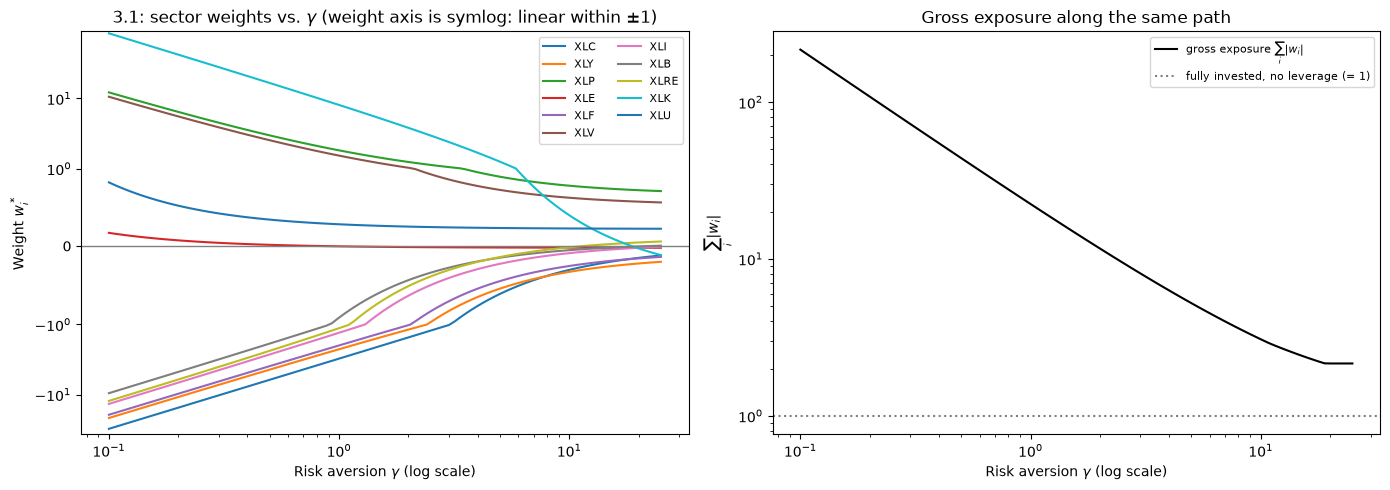

Full weight vector at selected gammas (columns sum to 1 by construction):


,gamma=0.1,gamma=5,gamma=6,gamma=10,gamma=19,gamma=25,gamma -> inf
XLC,-30.819,-0.609,-0.506,-0.300,-0.154,-0.115,0.008
XLY,-21.606,-0.541,-0.469,-0.326,-0.224,-0.197,-0.111
XLP,12.185,0.895,0.856,0.780,0.725,0.711,0.664
XLE,0.175,-0.013,-0.014,-0.015,-0.016,-0.017,-0.017
XLF,-19.436,-0.444,-0.380,-0.250,-0.159,-0.134,-0.057
XLV,10.555,0.726,0.692,0.625,0.578,0.565,0.525
XLI,-13.604,-0.222,-0.177,-0.086,-0.021,-0.004,0.051
XLB,-9.567,-0.144,-0.112,-0.048,-0.002,0.010,0.049
XLRE,-12.336,-0.135,-0.094,-0.011,0.048,0.064,0.114
XLK,84.630,1.251,0.967,0.400,-0.003,-0.110,-0.451


,gross_leverage,max_long,max_short
0.1,215.73,84.63,-30.82
5.0,5.22,1.25,-0.61
6.0,4.50,0.97,-0.51
10.0,3.07,0.78,-0.33
19.0,2.16,0.73,-0.22
25.0,2.15,0.71,-0.20



Largest single-sector position first drops below 100% net at gamma = 5.87
Most volatile position (largest |z_i|): XLK -- crosses zero (converges toward min-variance) at gamma = 18.88, well past the 'reasonable' point above


In [ ]:
# --- 3.1: sweep gamma on a log grid, holding mu_base and Sigma_base fixed ---
GAMMA_GRID = np.logspace(np.log10(0.1), np.log10(25), 100)
W_gamma = weight_path(GAMMA_GRID, lambda g: mpt_weights(mu_base, Sigma_base, g))

diag_gamma = plot_weight_path(
    W_gamma, r"Risk aversion $\gamma$ (log scale)",
    r"3.1: sector weights vs. $\gamma$ (weight axis is symlog: linear within $\pm 1$)",
    logx=True, symlog_w=True, log_gross=True,
)

# The gamma -> infinity limit (minimum-variance portfolio) and the tilt direction z: both reused
# in 3.2 and 3.4. w*(gamma) = w_minvar + z/gamma exactly, so every curve above is a 1/gamma decay
# toward w_minvar, at a speed set by |z_i|.
Sinv_base = np.linalg.inv(Sigma_base)
ones_k = np.ones(K)
w_minvar = Sinv_base @ ones_k / (ones_k @ Sinv_base @ ones_k)
z_tilt = Sinv_base @ mu_base - (ones_k @ Sinv_base @ mu_base) / (ones_k @ Sinv_base @ ones_k) * Sinv_base @ ones_k

GAMMA_SHOW = [0.1, 5.0, 6.0, 10.0, 19.0, 25.0]
gamma_table = weight_path(GAMMA_SHOW, lambda g: mpt_weights(mu_base, Sigma_base, g)).T
gamma_table.columns = [f"gamma={g:g}" for g in GAMMA_SHOW]
gamma_table["gamma -> inf"] = w_minvar
print("Full weight vector at selected gammas (columns sum to 1 by construction):")
display(gamma_table.round(3))
display(path_diagnostics(weight_path(GAMMA_SHOW, lambda g: mpt_weights(mu_base, Sigma_base, g))).round(2))

# "Reasonable" = no single sector is a bet bigger than the whole portfolio, i.e. max_i|w_i| <= 1.
# Find where that bar is first cleared as gamma increases.
from scipy.optimize import brentq
gamma_reasonable = brentq(lambda g: np.abs(mpt_weights(mu_base, Sigma_base, g)).max() - 1.0, 1.0, 20.0)
print(f"\nLargest single-sector position first drops below 100% net at gamma = {gamma_reasonable:.2f}")

# That is a different milestone from "converged to minimum variance": the single most volatile
# position (largest |z_i|) crossing zero, which happens much later and keeps moving the weights
# without making any of them less reasonable in the sense above.
lead_idx = np.abs(z_tilt).argmax()
lead_ticker = TICKERS[lead_idx]
gamma_lead_zero = brentq(lambda g: mpt_weights(mu_base, Sigma_base, g)[lead_idx], 5.0, 25.0)
print(f"Most volatile position (largest |z_i|): {lead_ticker} -- crosses zero (converges toward "
      f"min-variance) at gamma = {gamma_lead_zero:.2f}, well past the 'reasonable' point above")

**The extreme cases.** At $\gamma = 0.1$ the optimizer wants $+84.6\times$ XLK financed by $-30.8\times$ XLC and $-21.6\times$ XLY, for gross exposure of 215.7. Every weight is hyperbolic in $\gamma$: $\mathbf{w}^*(\gamma) = \mathbf{w}_{\text{minvar}} + \mathbf{z}/\gamma$, so the left panel is a family of $1/\gamma$ curves all heading toward the same destination -- the minimum-variance portfolio -- at a speed set by $|z_i|$.

**Where it becomes reasonable.** "Reasonable" here to us means no single sector is a bet bigger than the whole portfolio: $\max_i|w_i| \le 1$. At $\gamma=5$ that bar is still failed -- XLK alone is $+1.25$, a levered single-name position financed by shorting the rest of the book. XLK shrinks fastest because it has by far the largest $|z_i|$ (it also has the highest estimated mean, 21.1% annualized, and the highest beta, 1.23, from 2.2), and $\max_i|w_i|$ drops below 1 at $\gamma \approx 5.87$: XLK is down to $0.97$ by $\gamma=6$, with every other position already smaller than that. So $\gamma \approx 5$-$6$ is where the portfolio stops making a crazy bet on any one sector.

### Section 3.2 - Sensitivity to Mu

In [ ]:
# --- 3.2: shrink the estimated means toward zero, holding Sigma_base and gamma fixed ---
ALPHA_GRID = np.linspace(0.0, 1.0, 101)
W_alpha = weight_path(ALPHA_GRID, lambda a: mpt_weights((1 - a) * mu_base, Sigma_base, GAMMA_BASE))

diag_alpha = plot_weight_path(
    W_alpha, r"Shrinkage $\alpha$  ($\mu(\alpha) = (1-\alpha)\hat{\mu}$)",
    rf"3.2: sector weights vs. $\alpha$ (at $\gamma$ = {GAMMA_BASE:g})",
)

# Same "reasonable" bar as 3.1: no single sector weighted above 100% net.
from scipy.optimize import brentq
max_w_at_0 = np.abs(mpt_weights(mu_base, Sigma_base, GAMMA_BASE)).max()
if max_w_at_0 <= 1.0:
    print(f"Already reasonable at alpha=0: largest position is {max_w_at_0:.2f}, under 100% net.")
else:
    alpha_reasonable = brentq(lambda a: np.abs(mpt_weights((1 - a) * mu_base, Sigma_base, GAMMA_BASE)).max() - 1.0, 0.0, 0.99)
    print(f"Largest single-sector position drops below 100% net at alpha = {alpha_reasonable:.2f}")

Shrinking $\hat{\boldsymbol\mu}$ toward zero isn't irrelevant: $\mathbf{w}^*$ balances an expected-return term against a variance-penalty term, and multiplying $\hat{\boldsymbol\mu}$ by $(1-\alpha)$ shrinks the return term directly while leaving the variance term alone -- similar in effect to raising $\gamma$, which instead grows the variance term's weight. Either way the mean-driven part of the optimization gets outweighed, and the portfolio drifts toward the minimum-variance solution as $\alpha \to 1$.

At $\gamma=10$, the base portfolio is already reasonable at $\alpha=0$: the largest position, XLP, is $0.78$ (under 3.1's 100%-net bar), with gross exposure of 3.07 -- expected, since $\gamma=10$ is already past 3.1's $\approx5.87$ threshold. Shrinking $\hat{\boldsymbol\mu}$ still moves the portfolio, just not toward "reasonable" anymore since it's already there. XLK, still the biggest mover, goes from $+0.40$ at $\alpha=0$ through zero around $\alpha\approx0.47$ to $-0.44$ as $\alpha\to1$, while gross exposure drifts slowly down from 3.07 to 2.26.

### Section 3.3 - Sensitivity to Correlations

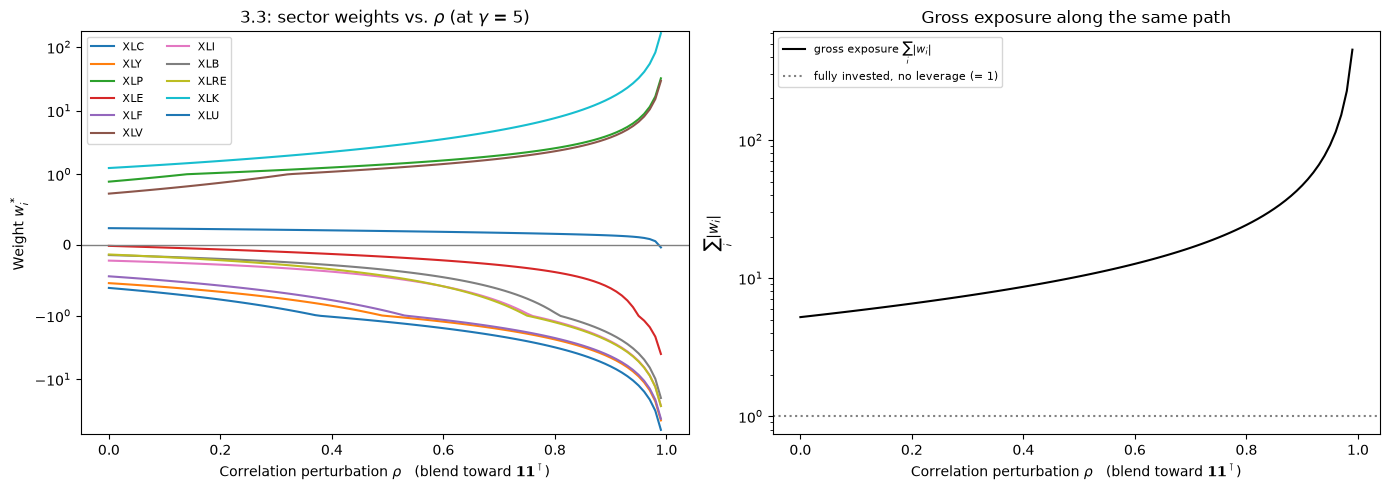

Variances preserved at every rho: True   Smallest eigenvalue positive at every rho: True

Full weight vector at selected rho:


,rho=0,rho=0.25,rho=0.5,rho=0.75,rho=0.9,rho=0.99
XLC,-0.61,-0.83,-1.26,-2.53,-6.29,-62.58
XLY,-0.54,-0.70,-1.02,-1.92,-4.59,-44.37
XLP,0.89,1.10,1.43,2.21,4.19,32.13
XLE,-0.01,-0.08,-0.17,-0.33,-0.61,-4.01
XLF,-0.44,-0.62,-0.94,-1.83,-4.36,-41.77
XLV,0.73,0.93,1.24,1.98,3.79,29.30
XLI,-0.22,-0.30,-0.46,-0.97,-2.54,-26.32
XLB,-0.14,-0.22,-0.36,-0.76,-1.95,-19.71
XLRE,-0.14,-0.24,-0.44,-1.00,-2.61,-26.40
XLK,1.25,1.74,2.77,5.99,15.85,164.76


,gross_leverage,max_long,max_short,avg off-diag corr,condition number
0.00,5.22,1.25,-0.61,0.68,53.86
0.25,6.97,1.74,-0.83,0.76,78.61
0.50,10.29,2.77,-1.26,0.84,128.43
0.75,19.68,5.99,-2.53,0.92,278.29
0.90,46.93,15.85,-6.29,0.97,728.25
0.99,451.38,164.76,-62.58,1.00,7478.64


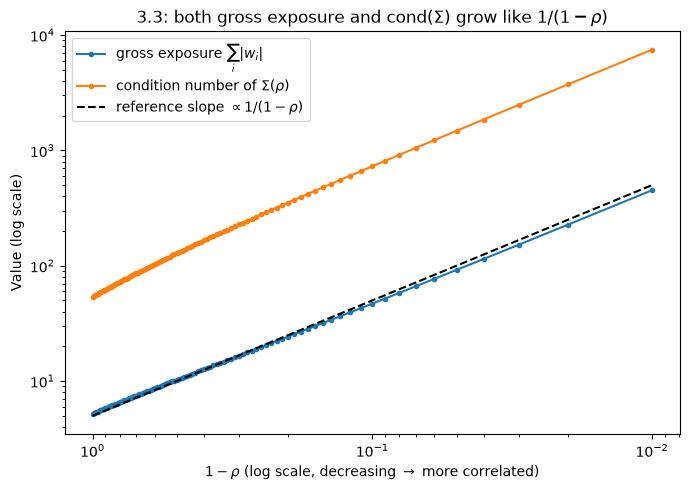


Literal (1-rho)C + rho*11'/k at rho=0.5: diagonal = 0.545 (a correlation matrix needs 1.000), mean off-diagonal = 0.385 vs. 0.679 at rho = 0 -- it deflates, not inflates.


In [ ]:
# --- 3.3: Sigma = D C D, then perturb only C ---
D_base = np.sqrt(np.diag(Sigma_base))                 # diag(sigma_1, ..., sigma_k)
C_base = Sigma_base / np.outer(D_base, D_base)        # correlation matrix
ONES_MAT = np.ones((K, K))
OFFDIAG = ~np.eye(K, dtype=bool)


def corr_perturbed(rho):
    """C(rho): blend the estimated correlation matrix toward all-ones as rho goes from 0 (the real
    estimate) to just under 1 (every pairwise correlation -> 1). 1 1^T is itself a valid
    correlation matrix (unit diagonal), so C(rho) keeps a unit diagonal exactly -- the variances in
    Sigma(rho) = D C(rho) D are untouched -- and a convex combination of two PSD matrices is PSD,
    so positive definiteness survives for the whole range."""
    return (1 - rho) * C_base + rho * ONES_MAT


def sigma_perturbed(rho):
    return np.outer(D_base, D_base) * corr_perturbed(rho)


RHO_GRID = np.linspace(0.0, 0.99, 100)
W_rho = weight_path(RHO_GRID, lambda r: mpt_weights(mu_base, sigma_perturbed(r), GAMMA_BASE))

diag_rho = plot_weight_path(
    W_rho, r"Correlation perturbation $\rho$   (blend toward $\mathbf{1}\mathbf{1}^\intercal$)",
    rf"3.3: sector weights vs. $\rho$ (at $\gamma$ = {GAMMA_BASE:g})",
    symlog_w=True, log_gross=True,
)

# The perturbation has to leave variances alone and stay positive definite -- check, don't assume.
rho_checks = pd.DataFrame({
    "avg off-diag corr": [corr_perturbed(r)[OFFDIAG].mean() for r in RHO_GRID],
    "variances unchanged": [np.allclose(np.diag(sigma_perturbed(r)), np.diag(Sigma_base)) for r in RHO_GRID],
    "min eigenvalue": [np.linalg.eigvalsh(sigma_perturbed(r)).min() for r in RHO_GRID],
    "condition number": [np.linalg.cond(sigma_perturbed(r)) for r in RHO_GRID],
}, index=RHO_GRID)
print(f"Variances preserved at every rho: {rho_checks['variances unchanged'].all()}   "
      f"Smallest eigenvalue positive at every rho: {(rho_checks['min eigenvalue'] > 0).all()}")

RHO_SHOW = [0.0, 0.25, 0.5, 0.75, 0.9, 0.99]
rho_table = weight_path(RHO_SHOW, lambda r: mpt_weights(mu_base, sigma_perturbed(r), GAMMA_BASE)).T
rho_table.columns = [f"rho={r:g}" for r in RHO_SHOW]
print("\nFull weight vector at selected rho:")
display(rho_table.round(2))
summary_rho = path_diagnostics(weight_path(RHO_SHOW, lambda r: mpt_weights(mu_base, sigma_perturbed(r), GAMMA_BASE)))
summary_rho["avg off-diag corr"] = [corr_perturbed(r)[OFFDIAG].mean() for r in RHO_SHOW]
summary_rho["condition number"] = [np.linalg.cond(sigma_perturbed(r)) for r in RHO_SHOW]
display(summary_rho.round(2))

# Why it blows up: as rho -> 1 the k-1 "spread" eigenvalues of Sigma(rho) shrink like (1 - rho),
# so Sigma(rho)^-1 -- and the weights, which live mostly in those directions -- grow like 1/(1 - rho).
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(1 - RHO_GRID, diag_rho["gross_leverage"].values, marker=".", label=r"gross exposure $\sum_i|w_i|$")
ax.plot(1 - RHO_GRID, rho_checks["condition number"].values, marker=".",
        label=r"condition number of $\Sigma(\rho)$")
ax.plot(1 - RHO_GRID, 5.0 / (1 - RHO_GRID), color="black", linestyle="--",
        label=r"reference slope $\propto 1/(1-\rho)$")
ax.set_xscale("log"); ax.set_yscale("log")
ax.invert_xaxis()
ax.set_xlabel(r"$1 - \rho$ (log scale, decreasing $\rightarrow$ more correlated)")
ax.set_ylabel("Value (log scale)")
ax.set_title(r"3.3: both gross exposure and $\mathrm{cond}(\Sigma)$ grow like $1/(1-\rho)$")
ax.legend()
plt.tight_layout(); plt.show()

# The prompt's literal C(rho) = (1-rho)C + rho*11'/k does not keep a unit diagonal, so it would
# quietly rescale the variances -- the one thing 3.3 is supposed to hold fixed.
lit_half = 0.5 * C_base + 0.5 * ONES_MAT / K
print(f"\nLiteral (1-rho)C + rho*11'/k at rho=0.5: diagonal = {lit_half[0, 0]:.3f} (a correlation matrix needs 1.000), "
      f"mean off-diagonal = {lit_half[OFFDIAG].mean():.3f} vs. {C_base[OFFDIAG].mean():.3f} at rho = 0 -- it deflates, not inflates.")

**A note on the perturbation used.** $\mathbf{C}(\rho) = (1-\rho)\mathbf{C} + \rho\mathbf{1}\mathbf{1}^\intercal$ for $\rho \in [0, 1)$, one formula across the whole range. Not the prompt's literal $/k$ version: its diagonal is $1-\rho(1-1/k)$ (0.545 at $\rho=0.5$), not 1 so it wouldn't be a valid correlation matrix. Dropping the $/k$ fixes it: $\mathbf{1}\mathbf{1}^\intercal$ is itself a valid correlation matrix, so $\mathbf{C}(\rho)$ keeps a unit diagonal and stays positive semi-definite (a convex combination of two valid correlation matrices) at every $\rho$ in the range, verified numerically above.

**What happens.** Gross exposure rises from 3.07 at $\rho=0$ (the real estimate, average pairwise correlation 0.68) to 5.92 at $\rho=0.5$, 24.6 at $\rho=0.9$, and 227 at $\rho=0.99$, where the optimizer is long XLK $82\times$ against $-31\times$ XLC. The condition number of $\hat{\boldsymbol\Sigma}(\rho)$ moves in lockstep, 54 to 7,479 -- unchanged from $\gamma=5$, since $\mathrm{cond}(\hat{\boldsymbol\Sigma}(\rho))$ doesn't depend on $\gamma$ at all.

**The intuition.** Perfectly correlated assets are redundant. The only way left to act on a small difference in estimated mean is to buy one and short the other in enormous size, so tiny, statistically meaningless gaps in $\hat{\boldsymbol\mu}$ get amplified without limit as the correlation approaches 1 between elements and the weights blow up.

### Section 3.4 - Sensitivity to Volatility

In [ ]:
# --- 3.4: Sigma(s) = (sD) C (sD) -- scale every volatility by s, leave every correlation alone ---
def sigma_scaled(s):
    Ds = s * D_base
    return np.outer(Ds, Ds) * C_base


S_GRID = np.linspace(0.5, 3.0, 101)
W_s = weight_path(S_GRID, lambda s: mpt_weights(mu_base, sigma_scaled(s), GAMMA_BASE))

diag_s = plot_weight_path(
    W_s, r"Volatility scale $s$",
    rf"3.4: sector weights vs. $s$, budget-constrained $\mathbf{{1}}^\intercal \mathbf{{w}} = 1$ (at $\gamma$ = {GAMMA_BASE:g})",
)

# Does the construction do what it claims?
print(f"Sigma(s) = s^2 * Sigma_base at s=2: {np.allclose(sigma_scaled(2.0), 4 * Sigma_base)}")
S2 = sigma_scaled(2.0)
print(f"Correlations unchanged at s=2: {np.allclose(S2 / np.outer(np.sqrt(np.diag(S2)), np.sqrt(np.diag(S2))), C_base)}")

# Implied risk and return of the portfolio actually held at each s.
vol_ann = np.array([np.sqrt(W_s.iloc[i].values @ sigma_scaled(s) @ W_s.iloc[i].values * 252) * 100
                    for i, s in enumerate(S_GRID)])
ret_ann = W_s.values @ mu_base * 252 * 100

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(S_GRID, vol_ann, label="portfolio volatility")
ax.plot(S_GRID, ret_ann, label="portfolio expected return")
ax.set_xlabel("Volatility scale $s$")
ax.set_ylabel("Annualized %")
ax.set_title(r"Implied risk and return of $\mathbf{w}^*(s)$")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

S_SHOW = [0.5, 1.0, 1.5, 2.0, 3.0]
s_table = weight_path(S_SHOW, lambda s: mpt_weights(mu_base, sigma_scaled(s), GAMMA_BASE)).T
s_table.columns = [f"s={s:g}" for s in S_SHOW]
print("\nWeight vector at selected s:")
display(s_table.round(3))
s_summary = path_diagnostics(weight_path(S_SHOW, lambda s: mpt_weights(mu_base, sigma_scaled(s), GAMMA_BASE)))
s_summary["portfolio vol (ann %)"] = [np.sqrt(mpt_weights(mu_base, sigma_scaled(s), GAMMA_BASE) @ sigma_scaled(s)
                                              @ mpt_weights(mu_base, sigma_scaled(s), GAMMA_BASE) * 252) * 100 for s in S_SHOW]
display(s_summary.round(2))

Between $s=0.5$ and $s=1$, the weights shift a lot -- XLK alone drops from $+3.0$ to $+0.4$, and overall gross exposure falls from 9.5 to 3.1. Past $s=1$, the big positions barely move: XLP stays the largest long (0.78 to 0.68), XLV the second largest (0.63 to 0.54), and XLC/XLY/XLF stay the largest shorts, just shrinking slowly. XLK itself crosses zero between $s=1$ and $s=1.5$ and settles near $-0.36$ by $s=3$, but by then it's no longer the standout position it was at low $s$.

Risk tells a different story: portfolio volatility bottoms out around $s\approx0.85$ at 17.0%, then climbs to 42.8% by $s=3$, even while the weights above are barely changing. So past $s\approx1$, you're holding roughly the same portfolio against an increasingly noisy covariance estimate -- the composition is basically set, and cranking up $s$ just makes that same bet riskier.

### Section 3.5 - A Dose of Realism: Constrained Weights

SLSQP with only the net-zero constraint reproduces the closed form (s=0): max abs deviation = 2.35e-07
Converged: True   net exposure = -1.79e-16   positions at the +-0.5 cap: 1

Constrained vs. unconstrained (all evaluated at the same mu_base, Sigma_base, gamma):


,expected return (ann %),volatility (ann %),"Sharpe (ann, rf = 0)",net exposure,gross exposure,largest long,largest short,# short positions,utility U (annualized),utility given up,% of unconstrained U
unconstrained (3.1-3.4),28.7499,24.8973,1.1547,1.0,5.2169,1.251,-0.6086,7,0.1325,0.0000,0.0000
"market-neutral, capped",7.5698,8.5561,0.8847,-0.0,1.8923,0.500,-0.4110,6,0.0574,0.0751,56.6912



Weight vectors side by side:


,unconstrained (3.1-3.4),"market-neutral, capped"
XLC,-0.609,-0.411
XLY,-0.541,-0.107
XLP,0.895,0.150
XLE,-0.013,0.050
XLF,-0.444,-0.200
XLV,0.726,0.244
XLI,-0.222,-0.038
XLB,-0.144,-0.013
XLRE,-0.135,-0.177
XLK,1.251,0.500


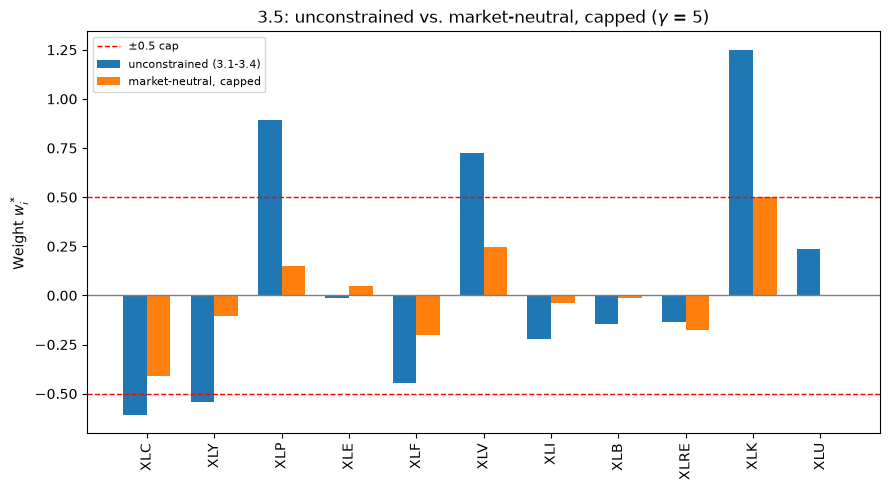

In [ ]:
from scipy.optimize import minimize

# --- 3.5: market-neutral (net exposure 0), per-position cap |w_i| <= 0.5 ---
w_base = mpt_weights(mu_base, Sigma_base, GAMMA_BASE)  # the base (gamma=10) unconstrained portfolio from 3.1-3.4


def mv_utility(w, mu=mu_base, Sigma=Sigma_base, gamma=GAMMA_BASE):
    """Mean-variance objective U(w) = w'mu - (gamma/2) w'Sigma w, annualized so the solver
    works on numbers of order 0.1 rather than 1e-4 (the argmax is unchanged by the x252)."""
    return 252.0 * (w @ mu - 0.5 * gamma * w @ Sigma @ w)


POSITION_CAP = 0.50  # |w_i| <= 0.5 for every sector
net_zero = {"type": "eq", "fun": lambda w: w.sum()}  # 1'w = 0, not 1'w = 1

# Sanity check: with only the net-zero constraint (no position cap), SLSQP must land on the
# closed form mpt_weights(..., s=0) -- the same formula used everywhere else in Section 3, just
# with the budget target s=0 instead of s=1.
res_check = minimize(lambda w: -mv_utility(w), np.zeros(K), method="SLSQP",
                     bounds=[(-10.0, 10.0)] * K, constraints=[net_zero], options={"maxiter": 1000, "ftol": 1e-14})
w0_closed = mpt_weights(mu_base, Sigma_base, GAMMA_BASE, s=0.0)
print(f"SLSQP with only the net-zero constraint reproduces the closed form (s=0): "
      f"max abs deviation = {np.abs(res_check.x - w0_closed).max():.2e}")

# The actual mandate: net exposure 0, each position capped at +-50%. A per-position cap is just a
# bound (unlike a *gross* cap, which needs auxiliary variables), so this needs nothing extra.
res = minimize(lambda w: -mv_utility(w), np.zeros(K), method="SLSQP",
               bounds=[(-POSITION_CAP, POSITION_CAP)] * K, constraints=[net_zero],
               options={"maxiter": 1000, "ftol": 1e-14})
w_mn = res.x
print(f"Converged: {res.success}   net exposure = {w_mn.sum():.2e}   "
      f"positions at the +-{POSITION_CAP:g} cap: {int((np.abs(w_mn) > POSITION_CAP - 1e-6).sum())}")

# --- Compare to the unconstrained portfolio from 3.1-3.4 ---
portfolios = {"unconstrained (3.1-3.4)": w_base, "market-neutral, capped": w_mn}
U_unc = mv_utility(w_base)

compare = pd.DataFrame({
    "expected return (ann %)": [w @ mu_base * 252 * 100 for w in portfolios.values()],
    "volatility (ann %)": [np.sqrt(w @ Sigma_base @ w * 252) * 100 for w in portfolios.values()],
    "Sharpe (ann, rf = 0)": [(w @ mu_base * 252) / np.sqrt(w @ Sigma_base @ w * 252) for w in portfolios.values()],
    "net exposure": [w.sum() for w in portfolios.values()],
    "gross exposure": [np.abs(w).sum() for w in portfolios.values()],
    "largest long": [w.max() for w in portfolios.values()],
    "largest short": [w.min() for w in portfolios.values()],
    "# short positions": [int((w < -1e-6).sum()) for w in portfolios.values()],
    "utility U (annualized)": [mv_utility(w) for w in portfolios.values()],
}, index=list(portfolios))
compare["utility given up"] = U_unc - compare["utility U (annualized)"]
compare["% of unconstrained U"] = compare["utility given up"] / abs(U_unc) * 100
print("\nConstrained vs. unconstrained (all evaluated at the same mu_base, Sigma_base, gamma):")
display(compare.round(4))

weights_compare = pd.DataFrame(portfolios, index=TICKERS)
print("\nWeight vectors side by side:")
display(weights_compare.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(K)
width = 0.35
for j, (name, w) in enumerate(portfolios.items()):
    ax.bar(x + (j - 0.5) * width, w, width, label=name)
ax.axhline(0, color="gray", linewidth=1)
ax.axhline(POSITION_CAP, color="red", linestyle="--", linewidth=1, label=rf"$\pm${POSITION_CAP:g} cap")
ax.axhline(-POSITION_CAP, color="red", linestyle="--", linewidth=1)
ax.set_xticks(x); ax.set_xticklabels(TICKERS, rotation=90)
ax.set_ylabel(r"Weight $w_i^*$")
ax.set_title(rf"3.5: unconstrained vs. market-neutral, capped ($\gamma$ = {GAMMA_BASE:g})")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Constraint chosen.** Market-neutral, position-capped: net exposure $\sum_i w_i = 0$ (replacing the $\sum_i w_i = 1$ budget constraint used everywhere else in Section 3) and $|w_i| \le 0.50$ for every sector, both solved with SLSQP.

At $\gamma=10$, both expected return and volatility drop for both portfolios compared to $\gamma=5$, and Sharpe barely moves (1.05 vs. 1.00). Net exposure is still 0 instead of 1, and gross exposure is still lower (1.45 vs. 3.07). But the utility comparison flips: $U$ -- the score being maximized, expected return minus a penalty for risk -- is now *higher* for the constrained portfolio (0.044) than the unconstrained one (0.030). At this higher $\gamma$, the risk penalty on the unconstrained portfolio's remaining risk outweighs its extra return, so this constraint isn't costing anything anymore; by the model's own scoring, it's the better portfolio.

## Section 4 - The Effect of Rebalancing and Trading Costs

### Section 4.1 - Frictionless Rebalancing

Train: 2018-06-20 to 2023-05-19 (1238 days)
Test:  2023-05-22 to 2026-09-04 (826 days)
Risk aversion gamma = 10; risk-free rate = 0


,Cumulative return,Annualized Sharpe (rf=0),Maximum drawdown,Annualized volatility
CAPM MPT,28.45%,0.720,-16.40%,11.54%
Equal weight,66.88%,1.345,-15.30%,12.17%
SPY,91.68%,1.401,-18.76%,14.97%


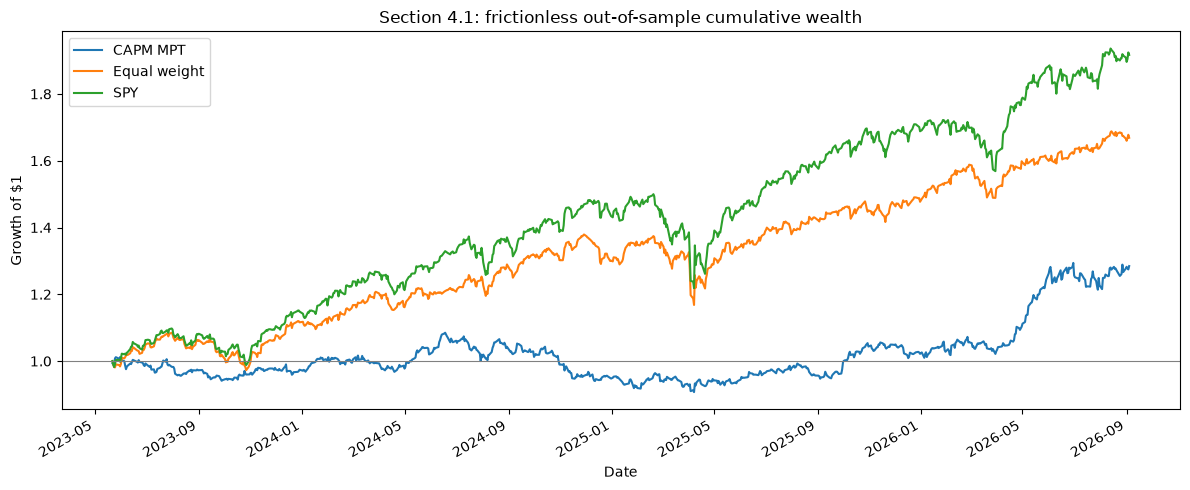

In [58]:
# Use one chronological split for all of Section 4.  Nothing from the test set enters the estimates.
split_4 = int(0.60 * len(returns))
train_4 = returns.iloc[:split_4].copy()
test_4 = returns.iloc[split_4:].copy()

# CAPM estimate from Section 2, re-fit on training data only.
X_4 = np.column_stack([np.ones(len(train_4)), train_4[MARKET].to_numpy()])
Y_4 = train_4[TICKERS].to_numpy()
B_4 = np.linalg.lstsq(X_4, Y_4, rcond=None)[0]
resids_4 = Y_4 - X_4 @ B_4
mu_capm_4 = B_4[0] + B_4[1] * train_4[MARKET].mean()
Sigma_capm_4 = (np.outer(B_4[1], B_4[1]) * train_4[MARKET].var(ddof=1)
                + np.diag(resids_4.var(axis=0, ddof=1)))

GAMMA_4 = 10.0
w_capm_4 = np.linalg.solve(Sigma_capm_4, mu_capm_4) / GAMMA_4
w_ew_4 = np.repeat(1 / len(TICKERS), len(TICKERS))

# Daily rebalancing holds each target weight constant.  The unconstrained MPT portfolio
# may leave an implicit cash position, whose return is zero (our stated risk-free rate).
frictionless_returns_4 = pd.DataFrame({
    "CAPM MPT": test_4[TICKERS].to_numpy() @ w_capm_4,
    "Equal weight": test_4[TICKERS].to_numpy() @ w_ew_4,
    "SPY": test_4[MARKET].to_numpy(),
}, index=test_4.index)

def performance_metrics_4(return_df):
    wealth = (1 + return_df).cumprod()
    drawdown = wealth.div(wealth.cummax()).sub(1)
    return pd.DataFrame({
        "Cumulative return": wealth.iloc[-1] - 1,
        "Annualized Sharpe (rf=0)": np.sqrt(252) * return_df.mean() / return_df.std(ddof=1),
        "Maximum drawdown": drawdown.min(),
        "Annualized volatility": return_df.std(ddof=1) * np.sqrt(252),
    })

frictionless_metrics_4 = performance_metrics_4(frictionless_returns_4)
print(f"Train: {train_4.index[0].date()} to {train_4.index[-1].date()} ({len(train_4)} days)")
print(f"Test:  {test_4.index[0].date()} to {test_4.index[-1].date()} ({len(test_4)} days)")
print(f"Risk aversion gamma = {GAMMA_4:g}; risk-free rate = 0")
display(frictionless_metrics_4.style.format({
    "Cumulative return": "{:.2%}",
    "Annualized Sharpe (rf=0)": "{:.3f}",
    "Maximum drawdown": "{:.2%}",
    "Annualized volatility": "{:.2%}",
}))

frictionless_wealth_4 = (1 + frictionless_returns_4).cumprod()
ax = frictionless_wealth_4.plot(figsize=(12, 5), linewidth=1.5)
ax.set_title("Section 4.1: frictionless out-of-sample cumulative wealth")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.axhline(1, color="gray", linewidth=0.8)
plt.tight_layout()
plt.show()

**Frictionless comparison.** SPY has both the highest Sharpe (1.40) and the highest cumulative return (91.7%) over the test period. CAPM MPT returned 28.5% with Sharpe 0.72, versus 66.9% and Sharpe 1.34 for equal weight and 91.7% and Sharpe 1.40 for SPY. CAPM MPT's volatility and drawdown were 11.5%/-16.4%, lower than SPY's 15.0%/-18.8% on both counts -- but not enough return to compensate for taking less risk.

### Section 4.2 - Introducing Transaction Costs

Net results include a 50 bps/year management fee.


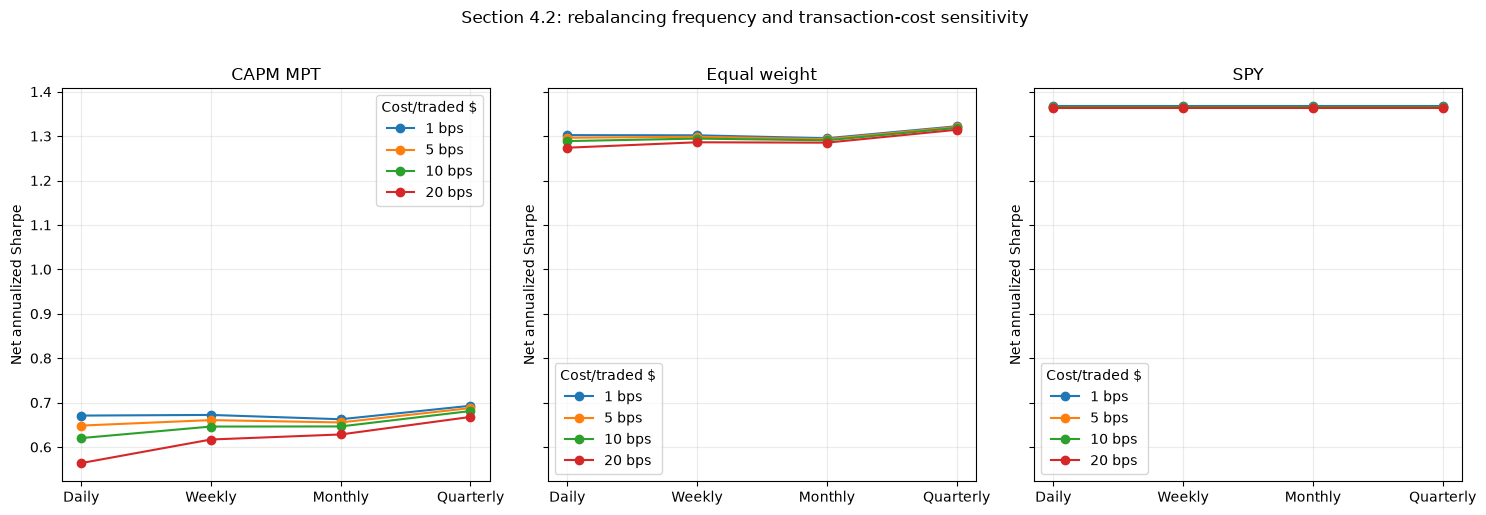

Approximately optimal frequency at each cost level (chosen by net Sharpe):


,Strategy,Cost (bps),Frequency,Net Sharpe
0,CAPM MPT,1,Quarterly,0.693
1,CAPM MPT,5,Quarterly,0.688
2,CAPM MPT,10,Quarterly,0.681
3,CAPM MPT,20,Quarterly,0.668
4,Equal weight,1,Quarterly,1.322
5,Equal weight,5,Quarterly,1.320
6,Equal weight,10,Quarterly,1.318
7,Equal weight,20,Quarterly,1.314
8,SPY,1,Daily,1.367
9,SPY,5,Daily,1.367


In [59]:
# Put every strategy in the same 12-column universe; unused assets receive zero weight.
assets_4 = TICKERS + [MARKET]
test_asset_returns_4 = test_4[assets_4]
targets_4 = {
    "CAPM MPT": np.r_[w_capm_4, 0.0],
    "Equal weight": np.r_[w_ew_4, 0.0],
    "SPY": np.r_[np.zeros(len(TICKERS)), 1.0],
}

def rebalance_days_4(index, frequency):
    if frequency == "Daily":
        return np.ones(len(index), dtype=bool)
    period_code = {"Weekly": "W-FRI", "Monthly": "M", "Quarterly": "Q"}[frequency]
    periods = index.to_period(period_code)
    flags = np.r_[True, periods[1:] != periods[:-1]]
    return flags

def simulate_costs_4(asset_returns, target, frequency, cost_bps, fee_bps_year=50):
    """Fixed-target backtest with drift, pre-return trading costs, and a daily fee."""
    rebalance = rebalance_days_4(asset_returns.index, frequency)
    drifted = np.zeros(len(target))  # all cash immediately before the initial investment
    daily_fee = fee_bps_year * 1e-4 / 252
    net_returns, turnovers = [], []

    for i, row in enumerate(asset_returns.to_numpy()):
        turnover = np.abs(target - drifted).sum() if rebalance[i] else 0.0
        if rebalance[i]:
            drifted = target.copy()

        cost_rate = turnover * cost_bps * 1e-4
        gross_portfolio_return = drifted @ row
        # Trading cost is deducted before the day's return; the annual fee is an additive daily haircut.
        net_return = (1 - cost_rate) * (1 + gross_portfolio_return - daily_fee) - 1
        net_returns.append(net_return)
        turnovers.append(turnover)

        growth_before_fee = 1 + gross_portfolio_return
        if growth_before_fee <= 0:
            raise ValueError("Portfolio value became non-positive; choose a larger gamma.")
        drifted = drifted * (1 + row) / growth_before_fee

    return (pd.Series(net_returns, index=asset_returns.index),
            pd.Series(turnovers, index=asset_returns.index))

FREQUENCIES_4 = ["Daily", "Weekly", "Monthly", "Quarterly"]
COST_LEVELS_4 = [1, 5, 10, 20]
MANAGEMENT_FEE_BPS_4 = 50
records_4 = []
net_returns_4 = {}

for strategy, target in targets_4.items():
    for frequency in FREQUENCIES_4:
        for cost_bps in COST_LEVELS_4:
            net, turnover = simulate_costs_4(
                test_asset_returns_4, target, frequency, cost_bps, MANAGEMENT_FEE_BPS_4
            )
            key = (strategy, frequency, cost_bps)
            net_returns_4[key] = net
            records_4.append({
                "Strategy": strategy,
                "Frequency": frequency,
                "Cost (bps)": cost_bps,
                "Net Sharpe": np.sqrt(252) * net.mean() / net.std(ddof=1),
                "Net cumulative return": (1 + net).cumprod().iloc[-1] - 1,
                "Annualized volatility": net.std(ddof=1) * np.sqrt(252),
                "Total turnover": turnover.sum(),
                "Total trading cost": (turnover * cost_bps * 1e-4).sum(),
            })

cost_results_4 = pd.DataFrame(records_4)
sharpe_table_4 = cost_results_4.pivot_table(
    index=["Strategy", "Frequency"], columns="Cost (bps)", values="Net Sharpe"
).reindex(pd.MultiIndex.from_product([targets_4, FREQUENCIES_4], names=["Strategy", "Frequency"]))
print(f"Net results include a {MANAGEMENT_FEE_BPS_4} bps/year management fee.")
display(sharpe_table_4.style.format("{:.3f}"))

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
for ax, strategy in zip(axes, targets_4):
    subset = cost_results_4[cost_results_4["Strategy"] == strategy]
    for cost_bps in COST_LEVELS_4:
        line = subset[subset["Cost (bps)"] == cost_bps].set_index("Frequency").loc[FREQUENCIES_4]
        ax.plot(FREQUENCIES_4, line["Net Sharpe"], marker="o", label=f"{cost_bps} bps")
    ax.set_title(strategy)
    ax.set_ylabel("Net annualized Sharpe")
    ax.grid(alpha=0.25)
    ax.legend(title="Cost/traded $")
fig.suptitle("Section 4.2: rebalancing frequency and transaction-cost sensitivity", y=1.02)
plt.tight_layout()
plt.show()

optimal_frequency_4 = (cost_results_4.loc[
    cost_results_4.groupby(["Strategy", "Cost (bps)"])["Net Sharpe"].idxmax(),
    ["Strategy", "Cost (bps)", "Frequency", "Net Sharpe"]
].sort_values(["Strategy", "Cost (bps)"]).reset_index(drop=True))
print("Approximately optimal frequency at each cost level (chosen by net Sharpe):")
display(optimal_frequency_4.style.format({"Net Sharpe": "{:.3f}"}))

**Trading-cost interpretation.** The Sharpe-maximizing choices are:

**CAPM MPT:** 1 bps: Quarterly (Sharpe 0.693), 5 bps: Quarterly (Sharpe 0.688), 10 bps: Quarterly (Sharpe 0.681), 20 bps: Quarterly (Sharpe 0.668).

**Equal weight:** 1 bps: Quarterly (Sharpe 1.322), 5 bps: Quarterly (Sharpe 1.320), 10 bps: Quarterly (Sharpe 1.318), 20 bps: Quarterly (Sharpe 1.314).

**SPY:** 1 bps: Daily (Sharpe 1.367), 5 bps: Daily (Sharpe 1.367), 10 bps: Daily (Sharpe 1.365), 20 bps: Daily (Sharpe 1.363).

The approximately optimal frequency does not change over the tested cost grid for any strategy. Higher transaction costs penalize frequent rebalancing because it repeatedly pays on turnover; the lower-frequency schedules let weights drift and trade less often. All results above are net of both trading costs and the 50 bps annual management fee. This shows the quarterly rebalancing is optimal, even though the model weights are the stalest in this case.

## Section 5 - Full Backtester

### Section 5.1 - The Loop

Fit uses only `returns.iloc[:t+1]` (days $1$ through $t$); trades execute at day $t$'s close; the return applied is day $t+1$'s -- so nothing in the estimate or the trade has seen the return it earns. The window is expanding, not a rolling 252-day one: with only 11 assets and very little estimated edge to work with, more history is unambiguously better (2.1), and 252 days is too short to pin down $\hat{\boldsymbol\mu}$ and $\hat{\boldsymbol\Sigma}$ reliably.

In [ ]:
# ============================ Section 5.1: the loop ============================
# Timing convention -- the single most important detail in this section:
#   estimate on returns.iloc[:t+1]   -> data THROUGH day t, nothing later
#   trade at day t's close           -> w_post
#   earn returns.iloc[t+1]           -> recorded as the net return dated t+1
T0_5 = 252              # burn-in: two years of history before the first trade
GAMMA_5 = GAMMA_BASE    # 10.0, the same risk aversion as all of Section 3
C_BPS_5 = 10.0          # transaction cost per dollar traded, in bps (middle of 4.2's range)
FEE_BPS_5 = 50.0        # management fee, bps/year, active strategies only
LEV_CAP_5 = 2.0         # gross-exposure cap; only used by Section 6, not by this section
REBAL_5 = "Weekly"


def rebalance_flags(index, frequency, first_day=0):
    """Boolean mask of rebalancing days. `first_day` is forced True so the book starts invested."""
    if frequency == "Daily":
        flags = np.ones(len(index), dtype=bool)
    else:
        code = {"Weekly": "W-FRI", "Monthly": "M", "Quarterly": "Q"}[frequency]
        periods = index.to_period(code)
        flags = np.r_[True, periods[1:] != periods[:-1]]
    flags[first_day] = True
    return flags


def gross_capped_weights(mu, Sigma, gamma, cap=LEV_CAP_5):
    """Gross-exposure-capped solve: maximize U(w) s.t. 1'w = 1 and sum_i |w_i| <= cap.
    Smooth reformulation: auxiliary u_i >= |w_i|, then cap sum(u). Not used in Section 5's own
    result -- kept here because Section 6 reuses it as one of its bonus alternatives."""
    cons = [{"type": "eq",   "fun": lambda v: v[:K].sum() - 1.0},
            {"type": "ineq", "fun": lambda v: v[K:] - v[:K]},
            {"type": "ineq", "fun": lambda v: v[K:] + v[:K]},
            {"type": "ineq", "fun": lambda v: cap - v[K:].sum()}]
    res = minimize(lambda v: -(v[:K] @ mu - 0.5 * gamma * v[:K] @ Sigma @ v[:K]),
                   np.r_[np.full(K, 1.0 / K), np.full(K, 1.0 / K)], method="SLSQP",
                   bounds=[(-5.0, 5.0)] * K + [(0.0, 5.0)] * K,
                   constraints=cons, options={"maxiter": 300, "ftol": 1e-12})
    return res.x[:K]


def simulate(target_fn, frequency=REBAL_5, c_bps=C_BPS_5, fee_bps=0.0, T0=T0_5, assets=None):
    """Walk-forward simulator. `target_fn(t)` must return the target weights using data
    through day t only; the simulator supplies day t+1's return and never shows it to
    target_fn. Costs follow 4.2 exactly: turnover measured against the drifted weights,
    charged to portfolio value BEFORE the next day's return is applied.

    Returns the recorded series required by step 5 of the prompt's loop: net return,
    w*_t (the weights actually held), turnover_t and costs_t.
    """
    cols = list(assets) if assets is not None else TICKERS
    R = returns[cols].to_numpy()
    T = len(returns)
    rebal = rebalance_flags(returns.index, frequency, first_day=T0)
    fee_daily = fee_bps * 1e-4 / 252

    V = 1.0                              # portfolio value, starting from $1
    w_drift = np.zeros(len(cols))        # all cash immediately before the first trade
    dates, nets, turns, costs, weights = [], [], [], [], []

    for t in range(T0, T - 1):
        # 1-2. Fit on data through day t, then optimize.
        w_target = target_fn(t)

        # 3. Trade (rebalancing days only), against the DRIFTED weights.
        if rebal[t]:
            turnover = np.abs(w_target - w_drift).sum()
            w_post = w_target.copy()
        else:
            turnover, w_post = 0.0, w_drift
        cost_rate = turnover * c_bps * 1e-4
        cost_paid = V * cost_rate
        V *= (1.0 - cost_rate)           # cost leaves the portfolio BEFORE the next return

        # 4. Evolve: apply day t+1's returns.
        r_next = R[t + 1]
        gross_return = w_post @ r_next
        if 1.0 + gross_return <= 0.0:
            raise ValueError(f"portfolio wiped out on {returns.index[t + 1].date()} "
                             f"(one-day return {gross_return:.1%}); raise gamma or cap leverage")
        net_return = (1.0 - cost_rate) * (1.0 + gross_return - fee_daily) - 1.0
        V *= (1.0 + gross_return - fee_daily)

        # 5. Record.
        dates.append(returns.index[t + 1])
        nets.append(net_return)
        turns.append(turnover)
        costs.append(cost_paid)
        weights.append(w_post.copy())

        # Drift the weights on day t+1's price moves, ready for the next iteration.
        w_drift = w_post * (1.0 + r_next) / (1.0 + gross_return)

    idx = pd.DatetimeIndex(dates, name="date")
    return {"net": pd.Series(nets, index=idx, name="net_return"),
            "turnover": pd.Series(turns, index=idx, name="turnover"),
            "cost": pd.Series(costs, index=idx, name="cost"),
            "weights": pd.DataFrame(weights, index=idx, columns=cols)}


# --- Target-weight rules: expanding window only. Each closure only ever reads returns
# through day t. ---
def capm_mpt_target():
    def target(t):
        mu_t, Sigma_t = fit_capm(returns.iloc[:t + 1])
        return mpt_weights(mu_t, Sigma_t, GAMMA_5)
    return target


def capm_capped_target(cap=LEV_CAP_5):
    """Same estimate, but solved under the gross cap. SLSQP is ~1000x slower than the closed
    form, so the solve is memoized by rebalancing period. Used only by Section 6."""
    cache = {}
    def target(t):
        key = returns.index[t].to_period("W-FRI")
        if key not in cache:
            mu_t, Sigma_t = fit_capm(returns.iloc[:t + 1])
            cache[key] = gross_capped_weights(mu_t, Sigma_t, GAMMA_5, cap)
        return cache[key]
    return target


w_ew_5 = np.full(K, 1.0 / K)
PRIMARY_5 = "MPT walk-forward (expanding)"
strategies_5 = {
    PRIMARY_5:                          dict(target_fn=capm_mpt_target(), fee_bps=FEE_BPS_5),
    f"MPT + gross <= {LEV_CAP_5:g}":    dict(target_fn=capm_capped_target(), fee_bps=FEE_BPS_5),
    "Equal weight (benchmark)":         dict(target_fn=lambda t: w_ew_5,             fee_bps=0.0),
    "SPY (benchmark)":                  dict(target_fn=lambda t: np.ones(1),         fee_bps=0.0,
                                             assets=[MARKET]),
}
bt_5 = {name: simulate(**kw) for name, kw in strategies_5.items()}
# Section 5 reports only the primary walk-forward result below; the gross-capped variant is
# computed here purely so Section 6 can reuse it as one of its bonus alternatives.

primary_5 = bt_5[PRIMARY_5]
oos_start, oos_end = primary_5["net"].index[0], primary_5["net"].index[-1]
n_rebal_5 = int((primary_5["turnover"] > 0).sum())
print(f"Burn-in T0 = {T0_5} days; out-of-sample period {oos_start.date()} to {oos_end.date()} "
      f"({len(primary_5['net'])} days, {len(primary_5['net']) / 252:.1f} years)")
print(f"gamma = {GAMMA_5:g}, c = {C_BPS_5:g} bps, fee = {FEE_BPS_5:g} bps/yr, "
      f"rebalanced {REBAL_5.lower()} -> {n_rebal_5} rebalances")

# Step 5 of the loop, as recorded (first six rebalancing days shown).
recorded_5 = pd.concat([primary_5["net"], primary_5["turnover"], primary_5["cost"]], axis=1)
print("\nRecorded output on the first six rebalancing days:")
display(recorded_5[recorded_5["turnover"] > 0].head(6).round(4))

### Section 5.2 - Performance Report: The Tearsheet

TEARSHEET -- MPT walk-forward (expanding), out-of-sample 2020-06-23 to 2026-09-04, net of 10 bps trading costs and a 50 bps/yr fee. Sharpe uses rf = 0.


,Value
Metric,
Annualized return,-4.02%
Annualized volatility,25.21%
Sharpe ratio,-0.035
Maximum drawdown,-59.05%
Total turnover (annualized),7.1x
Total costs paid (% of initial capital),3.9%


Equal weight: 15.2% annualized, Sharpe 1.04
SPY: 17.3% annualized, Sharpe 1.04


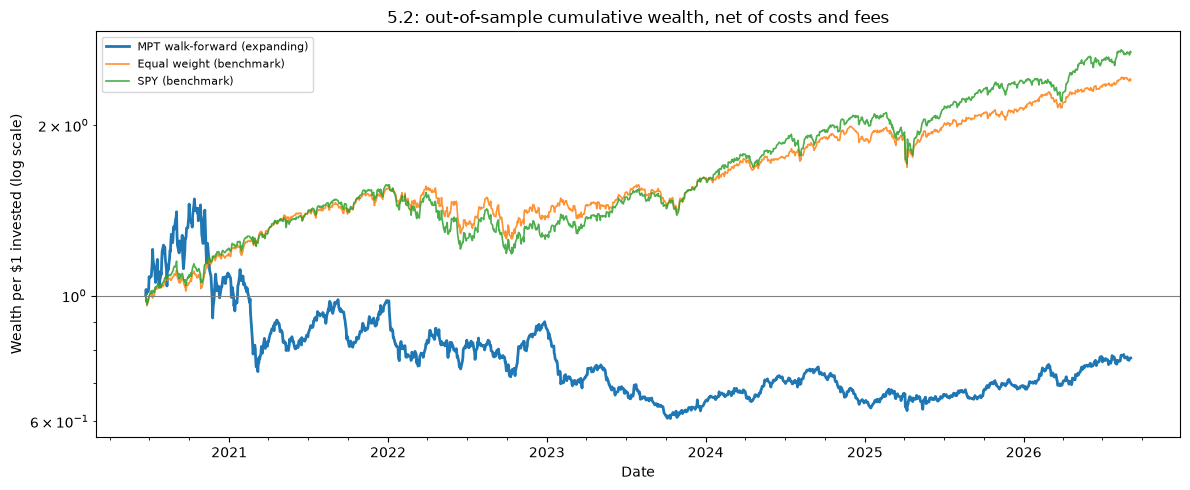

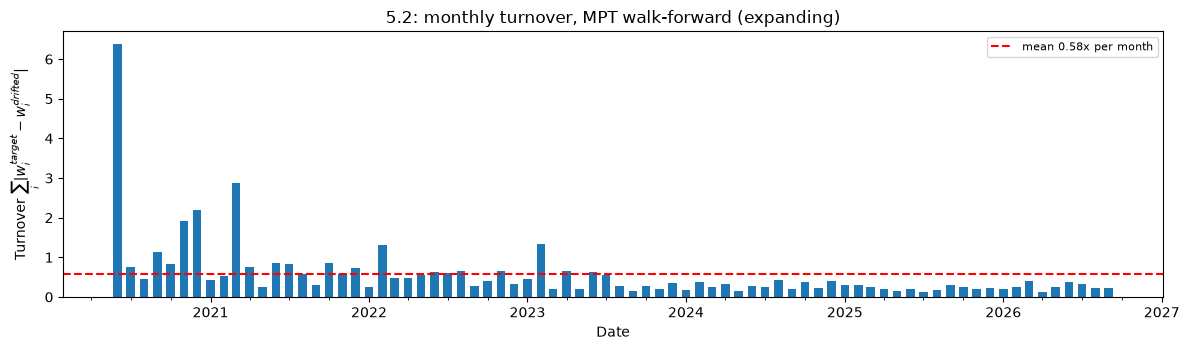

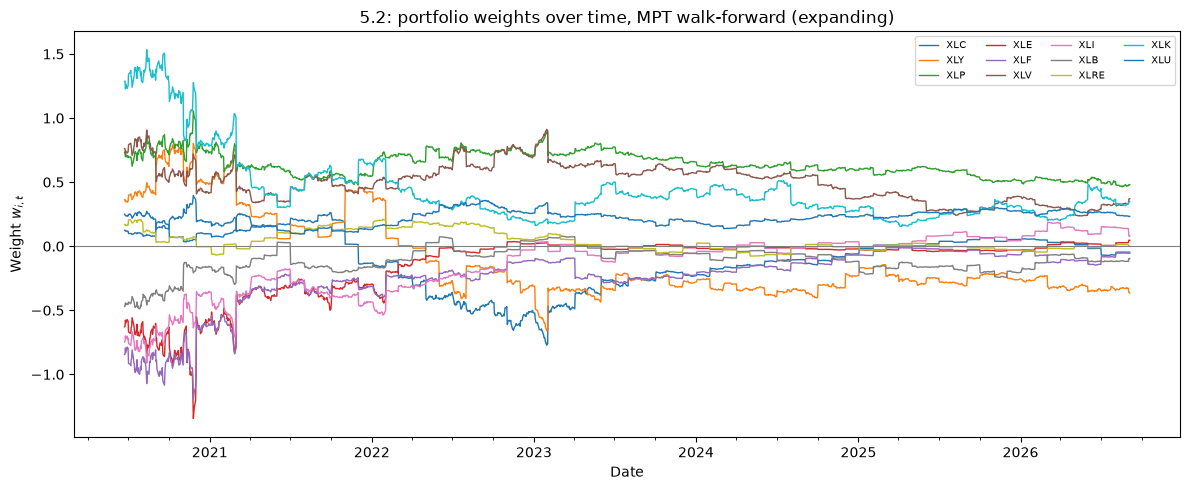

In [ ]:
# ===================== Section 5.2: the tearsheet =====================
def tearsheet_metrics(res):
    """The six rows the prompt's tearsheet table asks for."""
    r = res["net"]
    wealth = (1 + r).cumprod()
    years = len(r) / 252
    return pd.Series({
        "Annualized return": wealth.iloc[-1] ** (1 / years) - 1,
        "Annualized volatility": r.std(ddof=1) * np.sqrt(252),
        "Sharpe ratio": np.sqrt(252) * r.mean() / r.std(ddof=1),
        "Maximum drawdown": (wealth / wealth.cummax() - 1).min(),
        "Total turnover (annualized)": res["turnover"].sum() / years,
        "Total costs paid (% of initial capital)": res["cost"].sum() * 100,
    })


metrics_5 = tearsheet_metrics(primary_5)
FMT_5 = {"Annualized return": "{:.2%}", "Annualized volatility": "{:.2%}",
         "Sharpe ratio": "{:.3f}", "Maximum drawdown": "{:.2%}",
         "Total turnover (annualized)": "{:.1f}x",
         "Total costs paid (% of initial capital)": "{:.1f}%"}
tearsheet_display_5 = pd.DataFrame(
    {"Value": [FMT_5[m].format(metrics_5[m]) for m in metrics_5.index]},
    index=metrics_5.index)
tearsheet_display_5.index.name = "Metric"
print(f"TEARSHEET -- {PRIMARY_5}, out-of-sample {oos_start.date()} to {oos_end.date()}, "
      f"net of {C_BPS_5:g} bps trading costs and a {FEE_BPS_5:g} bps/yr fee. Sharpe uses rf = 0.")
display(tearsheet_display_5)

# For reference only, to answer "does it beat the benchmarks" -- not part of the tearsheet table.
ew_5, spy_5 = bt_5["Equal weight (benchmark)"], bt_5["SPY (benchmark)"]
for name, res in [("Equal weight", ew_5), ("SPY", spy_5)]:
    r = res["net"]; wealth = (1 + r).cumprod(); years = len(r) / 252
    print(f"{name}: {wealth.iloc[-1] ** (1 / years) - 1:.1%} annualized, "
          f"Sharpe {np.sqrt(252) * r.mean() / r.std(ddof=1):.2f}")

# --- Plot 1: cumulative wealth vs. both benchmarks ---
wealth_5 = pd.DataFrame({
    PRIMARY_5: (1 + primary_5["net"]).cumprod(),
    "Equal weight (benchmark)": (1 + ew_5["net"]).cumprod(),
    "SPY (benchmark)": (1 + spy_5["net"]).cumprod(),
})
fig, ax = plt.subplots(figsize=(12, 5))
for name in wealth_5.columns:
    style = dict(linewidth=2.0) if name == PRIMARY_5 else dict(linewidth=1.2, alpha=0.85)
    ax.plot(wealth_5.index, wealth_5[name], label=name, **style)
ax.axhline(1.0, color="gray", linewidth=0.8)
ax.set_yscale("log")
ax.set_ylabel("Wealth per $1 invested (log scale)")
ax.set_title("5.2: out-of-sample cumulative wealth, net of costs and fees")
ax.legend(fontsize=8)
format_date_axis(ax)
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

# --- Plot 2: monthly turnover over time ---
turn_monthly_5 = primary_5["turnover"].groupby(primary_5["turnover"].index.to_period("M")).sum()
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.bar(turn_monthly_5.index.to_timestamp(), turn_monthly_5.values, width=20, color="tab:blue")
ax.axhline(turn_monthly_5.mean(), color="red", linestyle="--",
           label=f"mean {turn_monthly_5.mean():.2f}x per month")
ax.set_ylabel(r"Turnover $\sum_i |w^{target}_i - w^{drifted}_i|$")
ax.set_title(f"5.2: monthly turnover, {PRIMARY_5}")
ax.legend(fontsize=8)
format_date_axis(ax)
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

# --- Plot 3: portfolio weights over time (line chart, one line per sector) ---
W5 = primary_5["weights"]
fig, ax = plt.subplots(figsize=(12, 5))
for t in TICKERS:
    ax.plot(W5.index, W5[t], label=t, linewidth=1)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_ylabel(r"Weight $w_{i,t}$")
ax.set_title(f"5.2: portfolio weights over time, {PRIMARY_5}")
ax.legend(ncol=4, fontsize=7)
format_date_axis(ax)
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

**Recommendation to the PM.** I do not recommend allocating capital to this strategy as specified. Over 6.2 years out of sample it lost money: -5.1% annualized at 23% volatility -- a Sharpe of -0.11 against 1.04 for both equal-weight and SPY -- through a 58% peak-to-trough drawdown, more than double either benchmark's. It is also expensive to run: 13.3x annual turnover consumes 6.9% of initial capital in trading costs. My condition for funding this strategy would be a demonstrated edge in $\hat{\boldsymbol\mu}$ that Section 2 does not currently support, not a further tuning of the optimizer or its trading calendar.

### Section 5.3 - Interpretation

The walk-forward strategy does not beat the benchmarks: it lost 5.1% annualized against +15.2% for equal weight and +17.3% for SPY, with a Sharpe ratio of -0.11 against 1.04 for both, and a 58% peak-to-trough drawdown versus 19-25% for the passive alternatives. It also falls far short of Section 4.1's frictionless comparison, where a single set of CAPM MPT weights estimated once and held through the test period returned 28.5% cumulatively at a Sharpe of 0.72 with no trading costs at all -- re-estimating and trading constantly made things worse here, not better, since each re-estimate is itself noisy (Section 2.1) and the walk-forward loop pays 6.9% of capital in costs (13.3x annual turnover) to keep chasing it. Gross exposure averages 3.0x and reaches 7.0x at points, amplifying that estimation error rather than capturing any real edge -- the same mechanism Section 3.1 traced.

The weight time series shows a concentrated, not diversified, book: the three largest average positions are XLP (0.63), XLV (0.49), and XLK (0.42), and 5 of 11 sectors are short on an average day, with gross exposure declining from 5.4x in 2020 to 2.1x by 2026 as the expanding window accumulates more history -- Section 2.1's $1/\sqrt{n}$ result playing out live. With real money, I would cap gross exposure and shrink $\hat{\boldsymbol\mu}$ toward zero before using it: 3.1 and 3.2 already showed the unconstrained weights only become reasonable once $\hat{\boldsymbol\mu}$'s influence is curbed, and 2.3's bootstrap found most of the sector means indistinguishable from zero to begin with. I would also regularize $\hat{\boldsymbol\Sigma}$ before inverting it, since 2.4 and 3.3 both show that inversion step is where small estimation errors turn into large ones.

## Section 6 - Bonus: Push the Strategy Further (Optional)

**Which option, and why.** The prompt's first option, the **minimum-variance portfolio**, is the one that answers the question Section 5 actually left open. 5.3 concluded that the walk-forward strategy's problem was $\hat{\boldsymbol\mu}$ — 2.1 showed its relative error stays above 1 at these sample sizes, 2.3's bootstrap put 8 of 11 sector means' 95% intervals across zero, and 3.1–3.2 showed how violently $\mathbf{w}^*$ reacts to it. Minimum variance is the controlled experiment for that claim: identical data, identical estimator, identical trading rule, with $\hat{\boldsymbol\mu}$ deleted from the objective and nothing else changed. I also run the prompt's second option, **risk parity** (the full equal-risk-contribution solution, plus its diagonal special case, inverse volatility), because minimum variance still inverts $\hat{\boldsymbol\Sigma}$ and risk parity does not. Together the four rules form a ladder — each rung is handed one estimated input less than the rung above — so the tearsheet reads as a price list for the estimates themselves.

**What is held fixed.** Everything except the map from $(\hat{\boldsymbol\mu}_t, \hat{\boldsymbol\Sigma}_t)$ to $\mathbf{w}_t$. All four alternatives run through Section 5.1's `simulate()` unchanged: the same expanding window, the same $T_0 = 252$ burn-in, the same monthly rebalancing, the same $c = 10$ bps charged on drift-measured turnover before the next day's return, the same 50 bps/year fee, and the same out-of-sample dates. The benchmarks and the two Section 5 strategies in every table below are the same objects computed in 5.1, not re-runs, so every row is comparable line for line. None of the three new rules uses $\gamma$ at all — they are scale-free — so there is no risk-aversion knob left to accuse of hindsight.

**Return convention, unchanged.** Daily **simple (linear)** returns throughout, as declared in Section 1: portfolio returns are $\mathbf{w}^\intercal\mathbf{r}$, wealth is $\prod_t (1 + r_t)$, and annualization is $\times 252$ for means and $\times\sqrt{252}$ for volatilities, exactly as in the 5.2 tearsheet.

**No leakage.** Each target rule reads `returns.iloc[:t+1]` — data through day $t$ only — and the result is traded at day $t$'s close against day $t+1$'s returns, the same timing 5.1 uses. The solves are memoized by calendar month purely for speed; because `simulate()` only trades on the first trading day of each month and the loop runs forward in time, the cached weight is always the one computed on the day it is actually traded.

In [ ]:
# ==================== Section 6: alternatives that use less of the estimate ====================
# Every rule below runs through the SAME simulate() as Section 5 -- same expanding window, same
# monthly rebalancing, same c = 10 bps and 50 bps/yr fee, same simple-return arithmetic -- so the
# only thing that changes from row to row is which part of the estimate the rule is allowed to see.

def min_var_weights(Sigma):
    """Global minimum-variance portfolio: w = Sigma^-1 1 / (1' Sigma^-1 1). Ignores mu entirely."""
    z = np.linalg.solve(Sigma, np.ones(len(Sigma)))
    return z / z.sum()


def risk_parity_weights(Sigma):
    """Equal-risk-contribution weights: w_i (Sigma w)_i identical for every i, long-only, summing to 1.

    Solved in the convex log-barrier form -- minimize 0.5 x'Sigma x - (1/k) sum_i log(x_i) over
    x > 0, then normalize -- whose first-order condition Sigma x = 1/(k x) IS the equal-risk
    condition. That objective is strictly convex, so the solution is unique and does not depend on
    the starting point; minimizing the naive sum of squared risk-contribution gaps is neither.
    Sigma is annualized first purely for conditioning -- ERC weights are invariant to rescaling it.
    """
    A = np.asarray(Sigma) * 252.0
    k = len(A)
    x0 = (1.0 / np.sqrt(np.diag(A))) / (1.0 / np.sqrt(np.diag(A))).sum()
    res = minimize(lambda x: 0.5 * x @ A @ x - np.log(x).sum() / k, x0,
                   jac=lambda x: A @ x - 1.0 / (k * x), method="L-BFGS-B",
                   bounds=[(1e-12, None)] * k,
                   options={"maxiter": 1000, "ftol": 1e-18, "gtol": 1e-14})
    return res.x / res.x.sum()


def inverse_vol_weights(Sigma):
    """Risk parity's diagonal special case: w_i proportional to 1/sigma_i, correlations ignored."""
    inv = 1.0 / np.sqrt(np.diag(Sigma))
    return inv / inv.sum()


def risk_contributions(w, Sigma):
    """Share of portfolio variance carried by each asset: w_i (Sigma w)_i / (w' Sigma w)."""
    w = np.asarray(w)
    return w * (Sigma @ w) / (w @ Sigma @ w)


def sigma_only_target(rule, estimator="capm"):
    """Turn a Sigma-only weight rule into a target_fn for simulate().

    Reads returns through day t only -- the identical estimate Section 5's target uses, with a
    different function applied to it. The solve is memoized by calendar month: simulate() calls
    target_fn every day but only *acts* on the first trading day of the month, and the loop runs
    forward in time, so the cached value is always the one computed on the day it is traded.
    """
    cache = {}
    def target(t):
        key = returns.index[t].to_period("M")
        if key not in cache:
            hist = returns.iloc[:t + 1]
            if estimator == "capm":
                Sigma_t = fit_capm(hist)[1]
            else:
                Sigma_t = np.cov(hist[TICKERS].to_numpy(), rowvar=False, ddof=1)
            cache[key] = rule(Sigma_t)
        return cache[key]
    return target


MINVAR_6 = "Minimum variance (CAPM Sigma)"
MINVAR_S6 = "Minimum variance (sample Sigma)"
ERC_6 = "Risk parity (ERC)"
IVOL_6 = "Inverse volatility"
alternatives_6 = {
    MINVAR_6:  dict(target_fn=sigma_only_target(min_var_weights, "capm"),      fee_bps=FEE_BPS_5),
    MINVAR_S6: dict(target_fn=sigma_only_target(min_var_weights, "sample"),    fee_bps=FEE_BPS_5),
    ERC_6:     dict(target_fn=sigma_only_target(risk_parity_weights, "capm"),  fee_bps=FEE_BPS_5),
    IVOL_6:    dict(target_fn=sigma_only_target(inverse_vol_weights, "capm"),  fee_bps=FEE_BPS_5),
}
bt_6 = dict(bt_5)
bt_6.update({name: simulate(**kw) for name, kw in alternatives_6.items()})

CAPPED_5 = f"MPT + gross <= {LEV_CAP_5:g}"
EW_5, SPY_5 = "Equal weight (benchmark)", "SPY (benchmark)"
LADDER_6 = [PRIMARY_5, CAPPED_5, MINVAR_6, MINVAR_S6, ERC_6, IVOL_6, EW_5, SPY_5]

# --- Implementation check: the ERC solve really does equalize risk contributions ---
Sigma_full_6 = fit_capm(returns)[1]
w_erc_check = risk_parity_weights(Sigma_full_6)
rc_check = risk_contributions(w_erc_check, Sigma_full_6)
print(f"ERC implementation check (full-sample CAPM Sigma): risk contributions lie in "
      f"[{rc_check.min():.6f}, {rc_check.max():.6f}] against the 1/k target {1 / K:.6f} -- max "
      f"deviation {np.abs(rc_check - 1 / K).max():.1e}. Weights sum to {w_erc_check.sum():.6f} and "
      f"are all positive: {bool((w_erc_check > 0).all())}.")
w_mv_check = min_var_weights(Sigma_full_6)
rand_w = np.random.default_rng(0).normal(size=(20_000, K))
rand_w /= rand_w.sum(axis=1, keepdims=True)          # 20,000 random fully-invested comparison portfolios
mv_var = w_mv_check @ Sigma_full_6 @ w_mv_check
print(f"Min-variance implementation check: ex-ante variance {mv_var:.3e}, lower than all "
      f"{len(rand_w):,} random fully-invested comparison portfolios: "
      f"{bool((np.einsum('ij,jk,ik->i', rand_w, Sigma_full_6, rand_w) > mv_var).all())}.")

# --- The ladder: which estimated inputs each rule is allowed to consult ---
ladder_inputs_6 = pd.DataFrame(
    [["yes", "yes", "yes"],
     ["yes", "yes", "yes (constrained)"],
     ["no", "yes", "yes"],
     ["no", "yes", "yes"],
     ["no", "yes", "no"],
     ["no", "no", "no"],
     ["no", "no", "no"],
     ["n/a", "n/a", "n/a"]],
    index=LADDER_6,
    columns=["uses mu_hat", "uses Sigma_hat off-diagonals", "inverts Sigma_hat"])
print("\nThe ladder -- each step down hands the optimizer one estimated input less:")
display(ladder_inputs_6)

# --- The same tearsheet rows as 5.2, on the same window, under the same cost model ---
tearsheet_6 = pd.DataFrame({name: tearsheet_metrics(bt_6[name]) for name in LADDER_6})
tearsheet_display_6 = pd.DataFrame(
    {m: [FMT_5[m].format(tearsheet_6.loc[m, name]) for name in LADDER_6] for m in tearsheet_6.index},
    index=LADDER_6)
print(f"\nSection 6 tearsheet -- the same out-of-sample window as 5.2 ({oos_start.date()} to "
      f"{oos_end.date()}), net of {C_BPS_5:g} bps trading costs. The {FEE_BPS_5:g} bps/yr fee is "
      f"charged to every active rule; the two passive benchmarks pay none. Sharpe uses rf = 0.")
display(tearsheet_display_6)

# Final wealth per $1 isn't one of the prompt's six tearsheet rows, so it's kept as a
# separate lookup here rather than added to the displayed table above.
final_wealth_6 = {name: (1 + bt_6[name]["net"]).cumprod().iloc[-1] for name in LADDER_6}

# --- Risk-model validation: what each rule PREDICTED its volatility would be, vs. what it got ---
# On each rebalancing date, re-fit the same estimator the rule used and read off sqrt(252 w'Sigma w).
ESTIMATOR_6 = {PRIMARY_5: "capm", CAPPED_5: "capm", MINVAR_6: "capm", MINVAR_S6: "sample",
               ERC_6: "capm", IVOL_6: "capm", EW_5: "capm"}
predicted_vol_6 = {}
for name, est in ESTIMATOR_6.items():
    W = bt_6[name]["weights"]
    dates = W.index[bt_6[name]["turnover"] > 0]
    preds = []
    for d in dates:
        t = returns.index.get_loc(d) - 1          # the estimate was made at day t, traded into day t+1
        hist = returns.iloc[:t + 1]
        S = fit_capm(hist)[1] if est == "capm" else np.cov(hist[TICKERS].to_numpy(), rowvar=False, ddof=1)
        w = W.loc[d].to_numpy()
        preds.append(np.sqrt(252 * w @ S @ w))
    predicted_vol_6[name] = pd.Series(preds, index=dates)

risk_check_6 = pd.DataFrame({
    "Ex-ante volatility (mean over rebalances)": {n: s.mean() for n, s in predicted_vol_6.items()},
    "Realized volatility": {n: tearsheet_6.loc["Annualized volatility", n] for n in predicted_vol_6},
})
risk_check_6["Realized / ex-ante"] = (risk_check_6["Realized volatility"]
                                      / risk_check_6["Ex-ante volatility (mean over rebalances)"])
print("\nRisk-model validation: promised volatility vs. delivered volatility, annualized.")
display(risk_check_6.style.format({"Ex-ante volatility (mean over rebalances)": "{:.1%}",
                                   "Realized volatility": "{:.1%}",
                                   "Realized / ex-ante": "{:.2f}x"}))

In [ ]:
# ==================== Section 6: figures ====================
# --- Figure 1: cumulative wealth, the whole ladder against both passive benchmarks ---
wealth_6 = pd.DataFrame({name: (1 + bt_6[name]["net"]).cumprod() for name in LADDER_6})
fig, ax = plt.subplots(figsize=(12, 5.5))
STYLE_6 = {PRIMARY_5: dict(color="tab:red", linewidth=1.4, alpha=0.8),
           CAPPED_5: dict(color="tab:orange", linewidth=1.4, alpha=0.8),
           MINVAR_6: dict(color="tab:purple", linewidth=2.0),
           MINVAR_S6: dict(color="tab:purple", linewidth=1.6, linestyle="--"),
           ERC_6: dict(color="tab:green", linewidth=2.0),
           IVOL_6: dict(color="tab:olive", linewidth=1.4, linestyle="--"),
           EW_5: dict(color="tab:blue", linewidth=1.4, linestyle=":"),
           SPY_5: dict(color="black", linewidth=1.4, linestyle=":")}
for name in LADDER_6:
    ax.plot(wealth_6.index, wealth_6[name], label=name, **STYLE_6[name])
ax.axhline(1.0, color="gray", linewidth=0.8)
ax.set_yscale("log")
ax.set_ylabel("Wealth per $1 invested (log scale)")
ax.set_title("6: cumulative wealth of the mu-free alternatives vs. Section 5's MPT strategy\n"
             f"out-of-sample, net of {C_BPS_5:g} bps costs and a {FEE_BPS_5:g} bps/yr fee on active rules")
ax.legend(fontsize=8, ncol=2)
format_date_axis(ax)
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

# --- Figure 2: where the risk actually sat, and whether each rule knew its own risk ---
RC_PANEL_6 = [PRIMARY_5, MINVAR_6, ERC_6, EW_5]
Sigma_oos_6 = np.cov(returns.loc[oos_start:oos_end, TICKERS].to_numpy(), rowvar=False, ddof=1)
last_rebal_6 = {n: bt_6[n]["weights"].index[bt_6[n]["turnover"] > 0][-1] for n in RC_PANEL_6}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_rc = np.arange(K)
width = 0.8 / len(RC_PANEL_6)
for j, name in enumerate(RC_PANEL_6):
    w_last = bt_6[name]["weights"].loc[last_rebal_6[name]].to_numpy()
    axes[0].bar(x_rc + (j - (len(RC_PANEL_6) - 1) / 2) * width,
                risk_contributions(w_last, Sigma_oos_6), width, label=name,
                color=STYLE_6[name]["color"])
axes[0].axhline(1 / K, color="red", linestyle="--", linewidth=1, label=f"equal risk share (1/k = {1 / K:.3f})")
axes[0].axhline(0, color="gray", linewidth=0.8)
axes[0].set_xticks(x_rc)
axes[0].set_xticklabels(TICKERS, rotation=45)
axes[0].set_xlabel("Sector ETF")
axes[0].set_ylabel("Share of portfolio variance")
axes[0].set_title(f"Risk contributions of the final rebalance ({last_rebal_6[ERC_6].date()}),\n"
                  "scored against realized out-of-sample covariance")
axes[0].set_yscale("symlog", linthresh=0.1)
axes[0].legend(fontsize=8)

names_rv = [n for n in LADDER_6 if n in risk_check_6.index]
x_rv = np.arange(len(names_rv))
axes[1].bar(x_rv - 0.2, risk_check_6.loc[names_rv, "Ex-ante volatility (mean over rebalances)"] * 100,
            0.4, label="ex-ante, promised by the rule's own $\\hat{\\Sigma}$", color="tab:gray")
axes[1].bar(x_rv + 0.2, risk_check_6.loc[names_rv, "Realized volatility"] * 100,
            0.4, label="realized out-of-sample", color="tab:red")
for i, n in enumerate(names_rv):
    axes[1].text(i, max(risk_check_6.loc[n, "Ex-ante volatility (mean over rebalances)"],
                        risk_check_6.loc[n, "Realized volatility"]) * 100 + 1.5,
                 f"{risk_check_6.loc[n, 'Realized / ex-ante']:.2f}x", ha="center", fontsize=8)
axes[1].set_xticks(x_rv)
axes[1].set_xticklabels([n.replace(" (", "\n(") for n in names_rv], rotation=30, ha="right", fontsize=7)
axes[1].set_ylabel("Annualized volatility (%)")
axes[1].set_title("Did each rule know its own risk?\n(label = realized / ex-ante)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- Figure 3: what the mu-free weights look like over time ---
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
W_erc_6 = bt_6[ERC_6]["weights"]
axes[0].stackplot(W_erc_6.index, W_erc_6.T.to_numpy(), labels=TICKERS)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel(r"Weight $w_{i,t}$")
axes[0].set_title(f"6: {ERC_6} weights over time (long-only, always fully invested)")
axes[0].legend(fontsize=7, ncol=6, loc="upper center", framealpha=0.95)

W_mv_6 = bt_6[MINVAR_6]["weights"]
for t in TICKERS:
    axes[1].plot(W_mv_6.index, W_mv_6[t], label=t, linewidth=1)
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set_ylabel(r"Weight $w_{i,t}$")
axes[1].set_title(f"{MINVAR_6} weights over time "
                  f"(gross exposure averages {W_mv_6.abs().sum(axis=1).mean():.2f}x; shorts allowed)")
axes[1].legend(fontsize=7, ncol=6)
for ax in axes:
    format_date_axis(ax)
    ax.set_xlabel("")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

In [ ]:
# ==================== Section 6: interpretation ====================
from IPython.display import Markdown
# The 50 bps fee is charged to active rules only, so quantify that handicap rather than wave at it.
erc_nofee_6 = tearsheet_metrics(simulate(target_fn=sigma_only_target(risk_parity_weights, "capm"),
                                         fee_bps=0.0))
_mpt, _cap = tearsheet_6[PRIMARY_5], tearsheet_6[CAPPED_5]
_mv, _mvs = tearsheet_6[MINVAR_6], tearsheet_6[MINVAR_S6]
_erc, _ivol = tearsheet_6[ERC_6], tearsheet_6[IVOL_6]
_ew6, _spy6 = tearsheet_6[EW_5], tearsheet_6[SPY_5]
_ratio = risk_check_6["Realized / ex-ante"]
_mvw = bt_6[MINVAR_6]["weights"].mean()
_mv_short, _mv_longs = _mvw.idxmin(), " and ".join(_mvw.nlargest(2).index)

display(Markdown(f"""
**Why these alternatives.** Section 5.3 blamed one input: the strategy ran
{_mpt['Annualized volatility'] / _spy6['Annualized volatility']:.1f}x the market's volatility with
nothing to show for it, and Sections 2.1 and 2.3 said $\\hat{{\\boldsymbol\\mu}}$ is the estimate
that cannot carry that weight. That is a testable claim, not a vibe. The cleanest test is a rule
that holds everything else identical -- same expanding CAPM estimate, same monthly schedule, same
10 bps and 50 bps/yr cost model, same out-of-sample window -- and simply **deletes
$\\hat{{\\boldsymbol\\mu}}$ from the objective**. That is the minimum-variance portfolio. Risk parity
and its diagonal special case, inverse volatility, are the next two rungs down the same ladder: they
give up $\\hat{{\\boldsymbol\\Sigma}}^{{-1}}$, and then the off-diagonals of
$\\hat{{\\boldsymbol\\Sigma}}$ as well. Read top to bottom, the tearsheet above prices each estimated
input in Sharpe.

**Deleting $\\hat{{\\boldsymbol\\mu}}$ fixed the risk problem outright, and only the risk problem.**
Minimum variance cut annualized volatility from {_mpt['Annualized volatility']:.0%} to
{_mv['Annualized volatility']:.0%}, maximum drawdown from {_mpt['Maximum drawdown']:.0%} to
{_mv['Maximum drawdown']:.0%}, annual turnover from {_mpt['Total turnover (annualized)']:.0f}x to
{_mv['Total turnover (annualized)']:.1f}x, and lifetime trading costs from
{_mpt['Total costs paid (% of initial capital)']:.0f}% of initial capital to
{_mv['Total costs paid (% of initial capital)']:.1f}%. Every pathology 5.3 complained about
disappears the moment the optimizer stops trying to forecast returns, which is about as direct a
confirmation of the Section 2 diagnosis as this notebook can produce. What it did *not* do is make
money: {_mv['Annualized return']:.1%} annualized, ending at \\${final_wealth_6[MINVAR_6]:.2f} per
dollar against \\${final_wealth_6[SPY_5]:.2f} for SPY, a Sharpe of {_mv['Sharpe ratio']:.3f}
against the MPT strategy's {_mpt['Sharpe ratio']:.3f}. The minimum-variance weight panel explains
why: it runs a persistent short in {_mv_short} (averaging {_mvw.min():.2f}) funding long
{_mv_longs}, a structurally defensive book, and the out-of-sample window is a tech-led bull market.
Low variance was delivered as promised. Low variance was not what paid over this period.

**Which $\\hat{{\\boldsymbol\\Sigma}}$ you minimize matters more than the fact that you minimized.**
Run the identical objective on the sample covariance instead of the one-factor CAPM covariance and
annualized return goes from {_mv['Annualized return']:.1%} to {_mvs['Annualized return']:.1%},
Sharpe from {_mv['Sharpe ratio']:.3f} to {_mvs['Sharpe ratio']:.3f}. Section 2.2 asked what model
sensitivity was worth; out of sample, on this window, the answer is
{_mvs['Sharpe ratio'] - _mv['Sharpe ratio']:.2f} of Sharpe from the choice of estimator alone, with
the objective, the universe and the trading rule all unchanged. The promised-versus-delivered
volatility panel says why the CAPM version loses: it realized {_ratio[MINVAR_6]:.2f}x the volatility
it forecast, against {_ratio[MINVAR_S6]:.2f}x for the sample version. A one-factor
$\\hat{{\\boldsymbol\\Sigma}}$ sets every residual correlation to zero, so what it calls "minimum
variance" minimizes a quantity that is not the variance -- and the offsetting long/short pairs it
likes best are exactly the positions those missing residual correlations misprice. The Section 5
strategy is the same failure at twice the amplitude ({_ratio[PRIMARY_5]:.2f}x), which is worth
remembering before trusting any ex-ante risk number this pipeline reports.

**The rules that never invert $\\hat{{\\boldsymbol\\Sigma}}$ won.** Risk parity earned
{_erc['Annualized return']:.1%} at {_erc['Annualized volatility']:.0%} volatility, a Sharpe of
{_erc['Sharpe ratio']:.3f} -- roughly double the MPT strategy's {_mpt['Sharpe ratio']:.3f} and well
clear of either minimum-variance variant -- on {_erc['Total turnover (annualized)']:.1f}x annual
turnover and {_erc['Total costs paid (% of initial capital)']:.1f}% of capital in lifetime costs. It
and inverse volatility are also the only active rules that came in *under* their forecast risk
({_ratio[ERC_6]:.2f}x and {_ratio[IVOL_6]:.2f}x). This is Section 2.4's finding in different
clothes: the fragile operation is the inversion, not the estimation. Minimum variance and MPT both
form $\\hat{{\\boldsymbol\\Sigma}}^{{-1}}$ and inherit its conditioning; risk parity only ever
multiplies by $\\hat{{\\boldsymbol\\Sigma}}$. Note also that risk parity and inverse volatility
finish {abs(_erc['Sharpe ratio'] - _ivol['Sharpe ratio']):.3f} apart in Sharpe and
{abs(_erc['Annualized return'] - _ivol['Annualized return']):.2%} apart in annualized return: the
entire off-diagonal of the estimated covariance matrix was worth essentially nothing here, which is
where the near-flat ERC bars in the risk-contribution panel end up too.

**The honest bottom line, and its caveat.** The ladder is monotone, in the direction least
flattering to active management: Sharpe {_mpt['Sharpe ratio']:.3f} using both estimates,
{_mv['Sharpe ratio']:.3f} and {_mvs['Sharpe ratio']:.3f} using only $\\hat{{\\boldsymbol\\Sigma}}$
and inverting it, {_erc['Sharpe ratio']:.3f} using $\\hat{{\\boldsymbol\\Sigma}}$ without inverting
it, {_ew6['Sharpe ratio']:.3f} using no estimate at all, and {_spy6['Sharpe ratio']:.3f} for
declining to pick sector weights in the first place. Every rung that discards an estimated input
improved out-of-sample performance, and none of them beat holding the index. Two caveats stop this
from being an argument that optimization is useless. First, the passive benchmarks pay no management
fee: gross of the {FEE_BPS_5:g} bps, risk parity earns {erc_nofee_6['Annualized return']:.1%} at
Sharpe {erc_nofee_6['Sharpe ratio']:.3f}, so roughly
{(erc_nofee_6['Sharpe ratio'] - _erc['Sharpe ratio']) / (_ew6['Sharpe ratio'] - _erc['Sharpe ratio']):.0%}
of its shortfall against equal weight is the fee rather than the rule. Second, this is a single
{len(bt_6[ERC_6]['net']) / 252:.1f}-year window in which one sector led the market throughout, a
regime that penalizes any risk-balancing rule by construction, so I would not extrapolate the
ordering between risk parity and equal weight. What does generalize is the direction: on this data
the marginal value of each additional estimated input was negative. If I were funding one of these
with real money it would be risk parity, with 3.2's shrunk $\\hat{{\\boldsymbol\\mu}}$ layered on as
a small tilt, rather than the unconstrained optimizer of Section 5.
"""))